In [145]:


# Data manipulation and numerical computing
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt

# Machine learning preprocessing
# Used to apply different preprocessing steps to numerical
# and categorical variables.
from sklearn.compose import ColumnTransformer

# Used to combine preprocessing and the machine learning
# model into a single workflow.
from sklearn.pipeline import Pipeline

# One-hot encode categorical variables and standardise
# numerical variables.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Fill missing values before model training.
from sklearn.impute import SimpleImputer

# Baseline machine learning model
from sklearn.linear_model import LogisticRegression

# Tree-based ensemble model used as an additional benchmark.
from sklearn.ensemble import RandomForestClassifier

# Model evaluation metrics
# These metrics assess classification performance and help
# compare different machine learning models.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    average_precision_score
)


In [146]:

# Define the file path of the horse racing dataset
file_path = r"C:\Users\Ayush\Desktop\raceform.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Display the first five records to verify the dataset loaded correctly
df.head()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_22872\18969160.py:5: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,date,course,race_id,off,race_name,type,class,pattern,rating_band,age_band,...,trainer,prize,or,rpr,ts,sire,dam,damsire,owner,comment
0,2015-01-01,Catterick,615704,12:30,Happy New Year Novices Hurdle,Hurdle,Class 4,NaN,NaN,4yo+,...,Brian Ellison,4873.5,–,114,80,Definite Article (GB),The Red Wench (IRE),Aahsaylad,P J Martin,Tracked leaders - effort 3 out - led approachi...
1,2015-01-01,Tramore (IRE),616859,12:35,2015 Waterford & Tramore Racecourse Supporters...,Hurdle,NaN,NaN,80-109,4yo+,...,P J Rothwell,NaN,81,–,–,Pyrus (USA),Lorli (IRE),Mukaddamah,Michael Cawe,Always in rear - never a factor - pulled up be...
2,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,NaN,NaN,NaN,5yo+,...,W P Mullins,€6037.50,–,122,32,Saint Des Saints (FR),Rainbow Crest (FR),Baryshnikov,Shanakiel Racing Syndicate,Soon chased leaders in 3rd - progress to dispu...
3,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,NaN,NaN,NaN,5yo+,...,Michael Winters,€1400,–,116,26,Blueprint (IRE),Garrisker (IRE),Kings Ride,John J Madden,Chased leaders in 4th until took closer order ...
4,2015-01-01,Tramore (IRE),616860,1:05,Padraig Curran - South East Cleaners Maiden Hu...,Hurdle,NaN,NaN,NaN,5yo+,...,Paul Nolan,€612.50,–,95,–,Librettist (USA),Zulbis (TUR),Down The Flag,D P Sharkey,Led from 1st until headed after 3 out - not qu...


In [147]:


# Display the first five rows to understand the dataset structure
print("First 5 rows of the dataset:")
print(df.head())

# Display the number of rows and columns in the dataset
print("\nDataset shape:")
print(df.shape)

# Display all column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types, non-null values and memory usage
print("\nDataset information:")
df.info()


First 5 rows of the dataset:
         date         course  race_id    off  \
0  2015-01-01      Catterick   615704  12:30   
1  2015-01-01  Tramore (IRE)   616859  12:35   
2  2015-01-01  Tramore (IRE)   616860   1:05   
3  2015-01-01  Tramore (IRE)   616860   1:05   
4  2015-01-01  Tramore (IRE)   616860   1:05   

                                           race_name    type    class pattern  \
0                      Happy New Year Novices Hurdle  Hurdle  Class 4     NaN   
1  2015 Waterford & Tramore Racecourse Supporters...  Hurdle      NaN     NaN   
2  Padraig Curran - South East Cleaners Maiden Hu...  Hurdle      NaN     NaN   
3  Padraig Curran - South East Cleaners Maiden Hu...  Hurdle      NaN     NaN   
4  Padraig Curran - South East Cleaners Maiden Hu...  Hurdle      NaN     NaN   

  rating_band age_band  ...          trainer     prize  or  rpr  ts  \
0         NaN     4yo+  ...    Brian Ellison    4873.5   –  114  80   
1      80-109     4yo+  ...     P J Rothwell       Na

In [148]:


# Remove the 'comment' column as it contains free-text race
# descriptions that are not required for this predictive model.
# 'errors="ignore"' prevents an error if the column is already absent.
df = df.drop(columns=["comment"], errors="ignore")

# Confirm that the column has been removed successfully
print("Comment column dropped successfully.")

# Display the first five rows after removing the column
print("\nFirst 5 rows after dropping 'comment':")
print(df.head())

# Display the updated list of columns
print("\nUpdated columns:")
print(df.columns.tolist())

Comment column dropped successfully.

First 5 rows after dropping 'comment':
         date         course  race_id    off  \
0  2015-01-01      Catterick   615704  12:30   
1  2015-01-01  Tramore (IRE)   616859  12:35   
2  2015-01-01  Tramore (IRE)   616860   1:05   
3  2015-01-01  Tramore (IRE)   616860   1:05   
4  2015-01-01  Tramore (IRE)   616860   1:05   

                                           race_name    type    class pattern  \
0                      Happy New Year Novices Hurdle  Hurdle  Class 4     NaN   
1  2015 Waterford & Tramore Racecourse Supporters...  Hurdle      NaN     NaN   
2  Padraig Curran - South East Cleaners Maiden Hu...  Hurdle      NaN     NaN   
3  Padraig Curran - South East Cleaners Maiden Hu...  Hurdle      NaN     NaN   
4  Padraig Curran - South East Cleaners Maiden Hu...  Hurdle      NaN     NaN   

  rating_band age_band  ...           jockey          trainer     prize  or  \
0         NaN     4yo+  ...  William Kennedy    Brian Ellison    487

In [149]:


# Calculate the number of missing values for each column
# and display the top 20 columns with the highest number
# of missing values.
print("Missing values by column:")

print(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

Missing values by column:
sex_rest       1602215
pattern        1577437
hg             1115768
rating_band    1074576
prize           834392
class           764979
draw            589313
sp                9052
num               6999
age_band           159
going               45
owner               35
damsire             21
trainer              9
dam                  5
jockey               2
off                  0
race_id              0
course               0
date                 0
dtype: int64


In [150]:


# List of categorical columns with missing values
categorical_missing_columns = [
    "owner",
    "damsire",
    "trainer",
    "dam",
    "jockey"
]

# Replace missing values with 'Unknown' to retain all
# observations and allow missing values to be treated as
# a separate category during one-hot encoding.
for col in categorical_missing_columns:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

In [151]:
# ==========================================================
# 5. MISSING-VALUE ANALYSIS AND DATA CLEANING
# ==========================================================

# Calculate the number and percentage of missing values
# in each column.
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

# Sort columns from the highest to the lowest
# percentage of missing values.
missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
)

# Display the 25 columns with the most missing values.
print("Missing-value summary:")
print(missing_summary.head(25))


# ==========================================================
# 5.1 REMOVE HIGH-MISSING COLUMNS
# ==========================================================

# Identify columns where more than 60% of values are missing.
high_missing_columns = missing_summary.loc[
    missing_summary["missing_percentage"] > 60
].index.tolist()

print("\nColumns removed because more than 60% of values are missing:")
print(high_missing_columns)

# Remove columns with excessive missing data.
df = df.drop(
    columns=high_missing_columns,
    errors="ignore"
)


# ==========================================================
# 5.2 REMOVE POST-RACE AND LEAKAGE COLUMNS
# ==========================================================

# Remove variables that become available only after the race.
# The 'pos' column is retained temporarily because it is
# required later to create the Top-3 target variable.
leakage_columns_before_target = [
    "comment",
    "prize",
    "ovr_btn",
    "btn",
    "time",
    "rpr",
    "ts"
]

df = df.drop(
    columns=leakage_columns_before_target,
    errors="ignore"
)


# ==========================================================
# 5.3 REMOVE STARTING PRICE
# ==========================================================

# Remove Starting Price because betting-market odds are not
# included as predictors in the final model.
df = df.drop(
    columns=["sp"],
    errors="ignore"
)


# ==========================================================
# 5.4 HANDLE NUMERIC MISSING VALUES
# ==========================================================

# Select numerical columns that require type conversion
# and median imputation.
#
# The 'wgt' column is excluded because racing weights may
# use stone-pound notation, such as '9-7', and should be
# converted separately.
numeric_columns_to_clean = [
    "draw",
    "num",
    "age",
    "ran",
    "or"
]

for col in numeric_columns_to_clean:
    if col in df.columns:

        # Convert valid entries to numeric values.
        # Invalid values are converted to NaN.
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        # Create a binary feature showing whether the
        # original value was missing.
        df[f"{col}_missing"] = (
            df[col].isnull().astype(int)
        )

        # Replace missing values with the column median,
        # which is less affected by extreme values.
        df[col] = df[col].fillna(
            df[col].median()
        )


# ==========================================================
# 5.5 HANDLE CATEGORICAL MISSING VALUES
# ==========================================================

# Select categorical columns where missing values will be
# represented as a separate 'Unknown' category.
categorical_columns_to_clean = [
    "class",
    "age_band",
    "going",
    "owner",
    "damsire",
    "trainer",
    "dam",
    "jockey",
    "course",
    "type",
    "sex"
]

for col in categorical_columns_to_clean:
    if col in df.columns:

        # Preserve all rows by treating missing values
        # as a distinct category.
        df[col] = df[col].fillna("Unknown")


# ==========================================================
# 5.6 FINAL CHECK
# ==========================================================

# Display columns that still contain missing values.
remaining_missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

print("\nRemaining missing values:")
print(remaining_missing.head(20))

# Display the updated dimensions of the cleaned dataset.
print("\nCleaned dataset shape:")
print(df.shape)

Missing-value summary:
             missing_count  missing_percentage
sex_rest           1602215           87.104501
pattern            1577437           85.757444
hg                 1115768           60.658785
rating_band        1074576           58.419380
prize               834392           45.361764
class               764979           41.588123
draw                589313           32.038032
sp                    9052            0.492112
num                   6999            0.380501
age_band               159            0.008644
going                   45            0.002446
date                     0            0.000000
off                      0            0.000000
race_id                  0            0.000000
course                   0            0.000000
dist                     0            0.000000
pos                      0            0.000000
race_name                0            0.000000
type                     0            0.000000
ran                      0           

In [152]:

# Convert the finishing position ('pos') to a numeric format.
# Non-numeric values (e.g., PU, UR, F, BD) are converted to NaN.
df["position_numeric"] = pd.to_numeric(
    df["pos"],
    errors="coerce"
)

# Create the binary target variable:
# 1 = Horse finished in the Top 3
# 0 = Horse finished outside the Top 3 or did not finish.
df["top_3"] = np.where(
    df["position_numeric"].between(1, 3),
    1,
    0
)

In [153]:

# Remove the original finishing position columns after
# creating the target variable. Keeping these columns would
# introduce data leakage because they directly reveal the
# race outcome.
df = df.drop(
    columns=["pos", "position_numeric"],
    errors="ignore"
)

In [154]:
def convert_weight_to_pounds(value):
    """
    Convert horse racing weights from stone-pound format
    (e.g., '9-7') into total pounds.
    """

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    try:
        if "-" in value:
            stone, pounds = value.split("-", maxsplit=1)
            return float(stone) * 14 + float(pounds)

        return float(value)

    except (ValueError, TypeError):
        return np.nan

In [155]:
df["wgt_lbs"] = df["wgt"].apply(convert_weight_to_pounds)

In [156]:


# Create a binary indicator showing whether the original
# converted weight value was missing.
df["wgt_missing"] = (
    df["wgt_lbs"]
      .isnull()
      .astype(int)
)

# Replace missing converted weights with the median weight.
# Median imputation is preferred because it is less affected
# by extreme values than the mean.
df["wgt_lbs"] = df["wgt_lbs"].fillna(
    df["wgt_lbs"].median()
)

In [157]:
import pandas as pd
import numpy as np

# ==========================================================
# 1. LOAD ORIGINAL DATA
# ==========================================================

file_path = r"C:\Users\Ayush\Desktop\raceform.csv"

df = pd.read_csv(file_path)

print("Original shape:", df.shape)


# ==========================================================
# 2. REMOVE DUPLICATES AND UNUSED TEXT
# ==========================================================

# Remove completely duplicated rows.
df = df.drop_duplicates()

# Remove the unstructured race-comment field.
df = df.drop(
    columns=["comment"],
    errors="ignore"
)


# ==========================================================
# 3. CLEAN AND ENGINEER DATE FEATURES
# ==========================================================

# Convert the race date into datetime format.
# Invalid values are converted to NaT.
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Remove records without a valid race date.
df = df.dropna(subset=["date"])

# Extract calendar-based features from the race date.
df["race_year"] = df["date"].dt.year
df["race_month"] = df["date"].dt.month
df["race_day_of_week"] = df["date"].dt.dayofweek


# ==========================================================
# 4. CONVERT HORSE WEIGHT TO POUNDS
# ==========================================================

def convert_weight_to_pounds(value):
    """
    Convert racing weight from stone-pound format, such as
    '9-7', into total pounds.

    Returns NaN when the value cannot be converted.
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    try:
        if "-" in value:
            stone, pounds = value.split("-", maxsplit=1)
            return float(stone) * 14 + float(pounds)

        return float(value)

    except (ValueError, TypeError):
        return np.nan


# Apply the conversion function.
df["wgt_lbs"] = df["wgt"].apply(
    convert_weight_to_pounds
)

# Record whether the converted weight was originally missing.
df["wgt_missing"] = (
    df["wgt_lbs"]
    .isnull()
    .astype(int)
)

# Replace missing converted weights with the median.
weight_median = df["wgt_lbs"].median()

if pd.notna(weight_median):
    df["wgt_lbs"] = df["wgt_lbs"].fillna(
        weight_median
    )

# Remove the original non-numeric weight column.
df = df.drop(
    columns=["wgt"],
    errors="ignore"
)


# ==========================================================
# 5. REMOVE HIGH-MISSING COLUMNS
# ==========================================================

# These columns contain substantial missing information
# and are excluded from the final dataset.
columns_to_drop = [
    "sex_rest",
    "pattern",
    "hg",
    "rating_band"
]

df = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)


# ==========================================================
# 6. REMOVE POST-RACE AND LEAKAGE FEATURES
# ==========================================================

# These variables become available only after the race.
# The finishing-position column 'pos' is retained temporarily
# because it is required to create the target variable.
post_race_columns = [
    "prize",
    "ovr_btn",
    "btn",
    "time",
    "rpr",
    "ts"
]

df = df.drop(
    columns=post_race_columns,
    errors="ignore"
)


# ==========================================================
# 7. CLEAN NUMERIC FEATURES
# ==========================================================

# Starting Price ('sp') is excluded because the final model
# does not use betting-market odds.
df = df.drop(
    columns=["sp"],
    errors="ignore"
)

numeric_columns = [
    "draw",
    "num",
    "age",
    "ran",
    "or"
]

for col in numeric_columns:
    if col in df.columns:

        # Convert invalid numeric values to NaN.
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        # Preserve information about original missingness.
        df[f"{col}_missing"] = (
            df[col]
            .isnull()
            .astype(int)
        )

        # Replace missing values with the median when
        # a valid median is available.
        median_value = df[col].median()

        if pd.notna(median_value):
            df[col] = df[col].fillna(
                median_value
            )


# ==========================================================
# 8. CLEAN CATEGORICAL FEATURES
# ==========================================================

categorical_columns = [
    "class",
    "age_band",
    "going",
    "owner",
    "damsire",
    "trainer",
    "dam",
    "jockey",
    "course",
    "type",
    "sex"
]

for col in categorical_columns:
    if col in df.columns:

        # Convert values into a consistent string type and
        # preserve missing entries as a separate category.
        df[col] = (
            df[col]
            .astype("string")
            .fillna("Unknown")
        )


# ==========================================================
# 9. CREATE TARGET VARIABLE
# ==========================================================

# Convert the finishing position into numeric format.
# Non-finish outcomes are converted to NaN.
df["position_numeric"] = pd.to_numeric(
    df["pos"],
    errors="coerce"
)

# Binary classification target:
# 1 = finished in positions 1, 2 or 3
# 0 = finished outside the Top 3 or did not finish
df["top_3"] = (
    df["position_numeric"]
    .between(1, 3)
    .astype(int)
)

# Optional secondary target:
# Keep this only if winner prediction is analysed later.
df["winner"] = (
    df["position_numeric"] == 1
).astype(int)


# ==========================================================
# 10. REMOVE TARGET-CREATION COLUMNS
# ==========================================================

# Remove columns that directly reveal the race outcome.
df = df.drop(
    columns=["pos", "position_numeric"],
    errors="ignore"
)


# ==========================================================
# 11. FINAL DATA-QUALITY CHECK
# ==========================================================

remaining_missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nRemaining missing values:")
print(remaining_missing.head(20))

print("\nCleaned dataset shape:")
print(df.shape)

print("\nTop-3 target distribution:")
print(df["top_3"].value_counts())

print("\nTop-3 target distribution (%):")
print(
    df["top_3"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nWeight conversion check:")
print(df["wgt_lbs"].describe())

C:\Users\Ayush\AppData\Local\Temp\ipykernel_22872\4021203868.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Original shape: (1839417, 37)

Remaining missing values:
date         0
course       0
race_id      0
off          0
race_name    0
type         0
class        0
age_band     0
dist         0
going        0
ran          0
num          0
draw         0
horse        0
age          0
sex          0
jockey       0
trainer      0
or           0
sire         0
dtype: int64

Cleaned dataset shape:
(1839417, 35)

Top-3 target distribution:
top_3
0    1276582
1     562835
Name: count, dtype: int64

Top-3 target distribution (%):
top_3
0    69.4
1    30.6
Name: proportion, dtype: float64

Weight conversion check:
count    1.839417e+06
mean     1.358821e+02
std      1.453789e+01
min      9.600000e+01
25%      1.260000e+02
50%      1.310000e+02
75%      1.490000e+02
max      1.790000e+02
Name: wgt_lbs, dtype: float64


In [158]:

# Remove the original finishing position columns after
# creating the target variable. Keeping these columns would
# introduce data leakage because they directly reveal the
# race outcome.
df = df.drop(
    columns=["pos", "position_numeric"],
    errors="ignore"
)

In [159]:
# Check which target-related columns still exist
target_columns = [
    col for col in ["pos", "position_numeric", "top_3"]
    if col in df.columns
]

print("Available target-related columns:", target_columns)

# Display only the columns that are still available
if target_columns:
    print(df[target_columns].head(20))

# Check the Top-3 target distribution
if "top_3" in df.columns:
    print("\nTop-3 class distribution:")
    print(df["top_3"].value_counts(dropna=False))

    print("\nTop-3 class distribution (%):")
    print(
        df["top_3"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )
else:
    print("\nThe 'top_3' column is not available.")

Available target-related columns: ['top_3']
    top_3
0       1
1       0
2       1
3       1
4       1
5       0
6       0
7       0
8       0
9       0
10      1
11      1
12      1
13      0
14      0
15      0
16      0
17      0
18      0
19      0

Top-3 class distribution:
top_3
0    1276582
1     562835
Name: count, dtype: int64

Top-3 class distribution (%):
top_3
0    69.4
1    30.6
Name: proportion, dtype: float64


In [160]:
print(df.isnull().sum())

date                0
course              0
race_id             0
off                 0
race_name           0
type                0
class               0
age_band            0
dist                0
going               0
ran                 0
num                 0
draw                0
horse               0
age                 0
sex                 0
jockey              0
trainer             0
or                  0
sire                0
dam                 0
damsire             0
owner               0
race_year           0
race_month          0
race_day_of_week    0
wgt_lbs             0
wgt_missing         0
draw_missing        0
num_missing         0
age_missing         0
ran_missing         0
or_missing          0
top_3               0
winner              0
dtype: int64


In [161]:
# Create the target variable only if it has not already
# been created. This prevents accidental overwriting when
# the notebook is executed multiple times.
if "top_3" not in df.columns:

    # Convert the original finishing position ('pos') into
    # numeric format. Non-numeric race outcomes such as
    # PU, UR, F and BD are converted to NaN.
    df["position_numeric"] = pd.to_numeric(
        df["pos"],
        errors="coerce"
    )

    # Create the binary classification target:
    # 1 = Horse finished in positions 1–3
    # 0 = Horse finished outside the Top 3 or
    #     did not complete the race.
    df["top_3"] = (
        df["position_numeric"]
        .between(1, 3)
        .fillna(False)
        .astype(int)
    )

In [162]:


# Display the number of observations in each target class.
# This helps identify whether the dataset is balanced or
# imbalanced before training the classification models.
print(df["top_3"].value_counts())

# Display the percentage distribution of each target class.
# Class percentages provide a clearer understanding of the
# degree of class imbalance in the dataset.
print("\nTarget percentage:")
print(
    df["top_3"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

top_3
0    1276582
1     562835
Name: count, dtype: int64

Target percentage:
top_3
0    69.4
1    30.6
Name: proportion, dtype: float64


In [163]:


# Convert the 'date' column to datetime format.
# Invalid or incorrectly formatted dates are converted to NaT.
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Remove records where the race date is missing or invalid,
# as these observations cannot be used to create date-based features.
df = df.dropna(subset=["date"])

# Extract the race year from the race date.
# This may capture long-term trends across different seasons.
df["race_year"] = df["date"].dt.year

# Extract the race month to capture seasonal effects
# that may influence horse racing performance.
df["race_month"] = df["date"].dt.month

# Extract the day of the week (Monday = 0, Sunday = 6).
# This feature may capture variations in race schedules.
df["race_day"] = df["date"].dt.dayofweek

In [164]:


# Create a dictionary that maps the numeric day values
# (generated from the datetime column) to their
# corresponding weekday names.
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

# Replace the numeric weekday values with descriptive
# weekday names to improve readability during
# exploratory data analysis and visualization.
df["race_day_name"] = df["race_day"].map(day_names)

In [165]:


# Draw a random sample from the cleaned dataset for
# exploratory data analysis (EDA). If the dataset contains
# fewer than 300,000 records, all available observations
# are used. A fixed random seed ensures reproducibility.
eda_df = df.sample(
    n=min(300000, len(df)),
    random_state=42
)

# Display the dimensions of the sampled dataset to confirm
# the number of observations available for analysis.
print("EDA sample shape:", eda_df.shape)

EDA sample shape: (300000, 37)


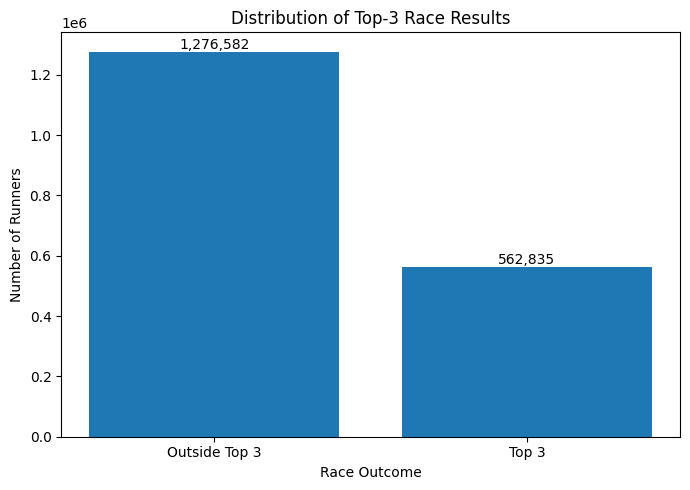

In [166]:


# Count the number of horses in each target class and
# sort the classes in ascending order (0, then 1).
target_counts = df["top_3"].value_counts().sort_index()

# Create descriptive labels for the binary target classes.
labels = ["Outside Top 3", "Top 3"]

# Retrieve the count for each class.
# The .get() method returns 0 if a class is absent.
values = [
    target_counts.get(0, 0),
    target_counts.get(1, 0)
]

# Create the bar chart.
plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values)

# Add chart title and axis labels.
plt.title("Distribution of Top-3 Race Results")
plt.xlabel("Race Outcome")
plt.ylabel("Number of Runners")

# Display the exact count above each bar to improve readability.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

# Adjust the layout to prevent overlapping elements.
plt.tight_layout()

# Display the completed figure.
plt.show()

## Distribution of Top-3 Race Results

The bar chart illustrates the distribution of the binary target variable (top_3) used for classification. Horses that finished **outside the Top 3** represent the majority class, with **1,276,582** observations, while **562,835** horses finished **within the Top 3**.

Although the dataset is moderately imbalanced, both classes contain a substantial number of observations, making the dataset suitable for supervised machine learning. This imbalance highlights the importance of evaluating models using metrics such as **Precision**, **Recall**, **F1-score**, and **PR-AUC**, rather than relying solely on accuracy, to ensure that the minority class is predicted effectively.

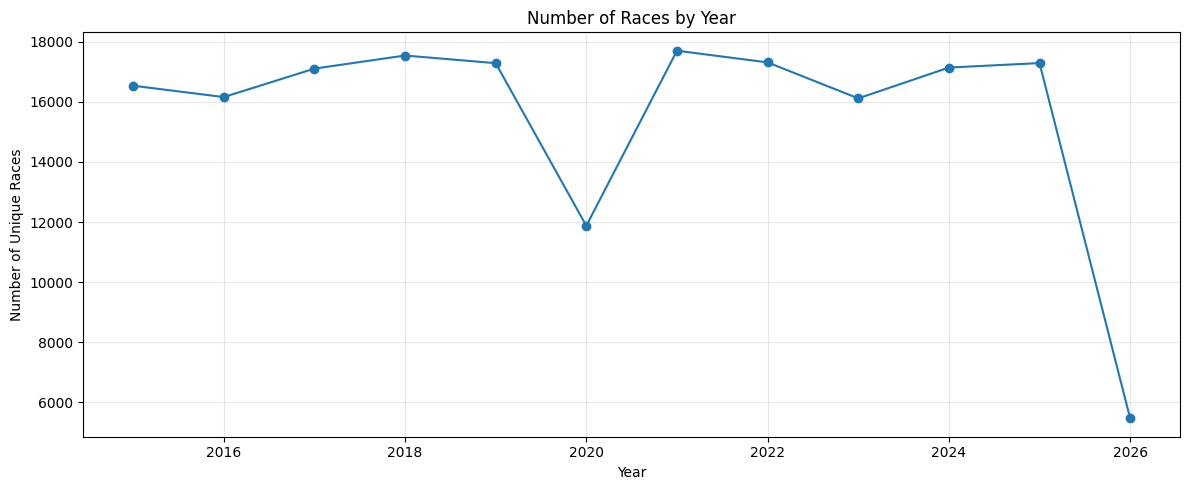

In [167]:


# Group the dataset by race year and count the number of
# unique races held in each year using the race ID.
races_by_year = (
    df.groupby("race_year")["race_id"]
    .nunique()
    .reset_index(name="number_of_races")
    .sort_values("race_year")
)

# Create a figure for the line chart.
plt.figure(figsize=(12, 5))

# Plot the annual number of unique races.
# Markers are added to make each yearly observation easier to identify.
plt.plot(
    races_by_year["race_year"],
    races_by_year["number_of_races"],
    marker="o"
)

# Add a descriptive title and axis labels.
plt.title("Number of Races by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Races")

# Display a light grid to improve readability.
plt.grid(alpha=0.3)

# Adjust the layout to prevent overlapping elements.
plt.tight_layout()

# Display the completed plot.
plt.show()

## Number of Races by Year

The line chart illustrates the annual number of unique horse races recorded in the dataset between **2015 and 2026**. The number of races remained relatively stable between **2015 and 2019**, averaging approximately **16,000–17,500 races** per year. A noticeable decline occurred in **2020**, which is likely attributable to the disruption of sporting events during the COVID-19 pandemic.

Following this decline, race activity recovered in **2021** and remained relatively consistent through **2025**, indicating that racing operations largely returned to normal levels. The substantial reduction observed in **2026** is likely due to the dataset containing only a partial year's data rather than representing a genuine decrease in racing activity.

Overall, the dataset demonstrates good temporal coverage across multiple years, making it suitable for analysing long-term racing patterns and developing predictive machine learning models.

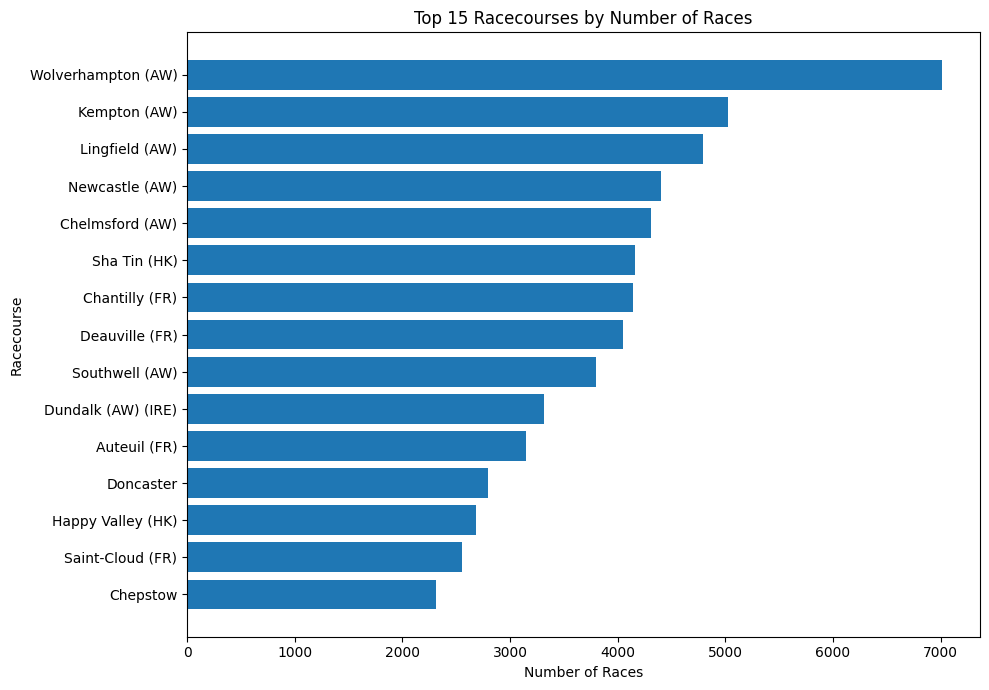

In [168]:

# Count the number of unique races held at each racecourse,
# select the top 15 courses with the highest race counts,
# and sort them in ascending order for a cleaner horizontal bar chart.
course_races = (
    df.groupby("course")["race_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

# Create the figure.
plt.figure(figsize=(10, 7))

# Plot the top 15 racecourses using a horizontal bar chart.
# Horizontal bars improve readability for longer course names.
plt.barh(
    course_races.index,
    course_races.values
)

# Add a descriptive title and axis labels.
plt.title("Top 15 Racecourses by Number of Races")
plt.xlabel("Number of Races")
plt.ylabel("Racecourse")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the completed chart.
plt.show()

## Top 15 Racecourses by Number of Races

The chart highlights the **15 racecourses** that hosted the greatest number of unique races within the dataset. **Wolverhampton (AW)** recorded the highest number of races by a considerable margin, followed by **Kempton (AW)** and **Lingfield (AW)**. A large proportion of the highest-ranked venues are **all-weather (AW)** racecourses, reflecting their ability to host racing throughout the year with fewer weather-related disruptions.

The chart also shows that the dataset includes racecourses from multiple countries, including the **United Kingdom, France, Hong Kong, and Ireland**, indicating good geographical diversity. This variation enhances the representativeness of the dataset and enables machine learning models to learn from races conducted under different racing environments and conditions.

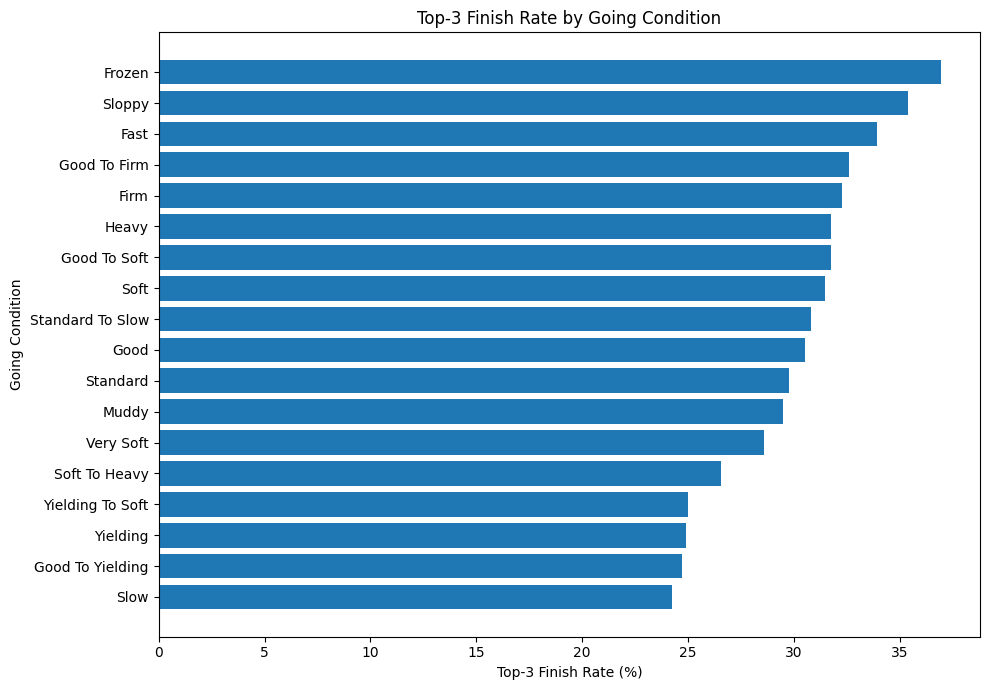

In [169]:

# Group the data by going condition and calculate:
# - the total number of runners
# - the number of Top-3 finishes
going_performance = (
    df.groupby("going")
    .agg(
        runners=("top_3", "size"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
)

# Calculate the Top-3 finish rate for each going condition.
going_performance["top_3_rate"] = (
    going_performance["top_3_finishes"]
    / going_performance["runners"]
)

# Retain only going conditions with at least 100 runners
# to ensure reliable and meaningful comparisons.
going_performance = going_performance[
    going_performance["runners"] >= 100
].sort_values(
    "top_3_rate",
    ascending=True
)

# Create the figure.
plt.figure(figsize=(10, 7))

# Plot the Top-3 finish rate for each going condition.
# Multiplying by 100 converts the rate into a percentage.
plt.barh(
    going_performance["going"],
    going_performance["top_3_rate"] * 100
)

# Add a descriptive title and axis labels.
plt.title("Top-3 Finish Rate by Going Condition")
plt.xlabel("Top-3 Finish Rate (%)")
plt.ylabel("Going Condition")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the completed chart.
plt.show()

## Top-3 Finish Rate by Going Condition

The chart compares the percentage of runners that achieved a **Top-3 finish** across different **going conditions**. Overall, the success rates vary within a relatively narrow range of approximately **25% to 37%**, indicating that while track conditions may influence race outcomes, no single going condition overwhelmingly determines performance.

The highest Top-3 finish rates were observed under **Frozen**, **Sloppy**, and **Fast** conditions, whereas **Slow**, **Good to Yielding**, and **Yielding** recorded comparatively lower success rates. However, these differences should be interpreted with caution, as some going conditions occur much less frequently than others and may be represented by smaller sample sizes, despite applying a minimum threshold of 100 runners.

The variation observed across going conditions suggests that **track surface** may contribute useful predictive information and therefore represents a valuable feature for inclusion in machine learning models aimed at predicting race outcomes.

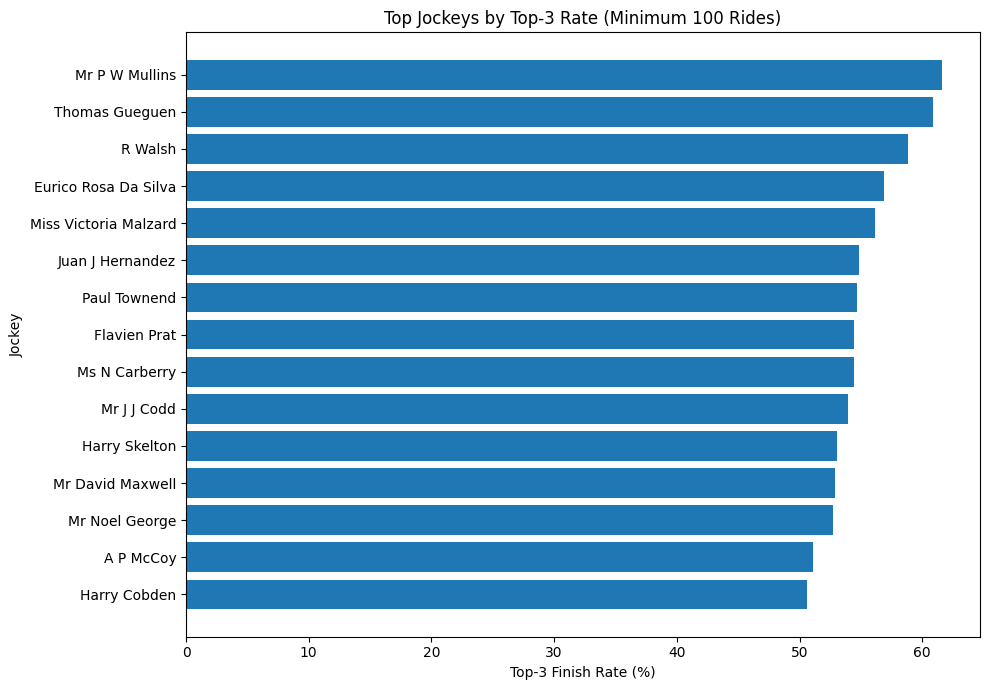

In [170]:

# Calculate each jockey's overall performance, including:
# - total number of rides
# - total wins
# - total Top-3 finishes
jockey_performance = (
    df.groupby("jockey")
    .agg(
        runners=("top_3", "size"),
        wins=("winner", "sum"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
)

# Calculate the winning percentage for each jockey.
jockey_performance["win_rate"] = (
    jockey_performance["wins"]
    / jockey_performance["runners"]
)

# Calculate the percentage of rides that resulted
# in a Top-3 finish.
jockey_performance["top_3_rate"] = (
    jockey_performance["top_3_finishes"]
    / jockey_performance["runners"]
)

# Set a minimum number of rides required for a jockey
# to be included in the comparison. This avoids
# misleading results from very small sample sizes.
minimum_jockey_rides = 100

# Select jockeys meeting the minimum ride threshold,
# rank them by Top-3 finish rate, keep the top 15,
# and sort them for a cleaner horizontal bar chart.
top_jockeys = (
    jockey_performance[
        jockey_performance["runners"] >= minimum_jockey_rides
    ]
    .sort_values("top_3_rate", ascending=False)
    .head(15)
    .sort_values("top_3_rate")
)

# Create the figure.
plt.figure(figsize=(10, 7))

# Plot the Top-3 finish rate for the best-performing jockeys.
plt.barh(
    top_jockeys["jockey"],
    top_jockeys["top_3_rate"] * 100
)

# Add a descriptive title and axis labels.
plt.title(
    f"Top Jockeys by Top-3 Rate "
    f"(Minimum {minimum_jockey_rides} Rides)"
)

plt.xlabel("Top-3 Finish Rate (%)")
plt.ylabel("Jockey")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the completed chart.
plt.show()

## Top Jockeys by Top-3 Finish Rate

The chart ranks the **15 highest-performing jockeys** based on their **Top-3 finish rate**, considering only jockeys with a minimum of **100 rides** to ensure statistically reliable comparisons. The highest success rates were achieved by **Mr P W Mullins**, **Thomas Gueguen**, and **R Walsh**, each recording Top-3 finish rates exceeding **58%**.

Most of the leading jockeys achieved Top-3 finish rates between **50% and 62%**, demonstrating a high level of consistency across a substantial number of rides. This suggests that jockey performance varies considerably and may have a meaningful influence on race outcomes.

The findings indicate that **jockey-related information** is likely to be an informative predictor in machine learning models. Variables describing jockey experience, historical performance, or recent form may therefore improve the model's ability to predict whether a horse will finish in the Top 3.

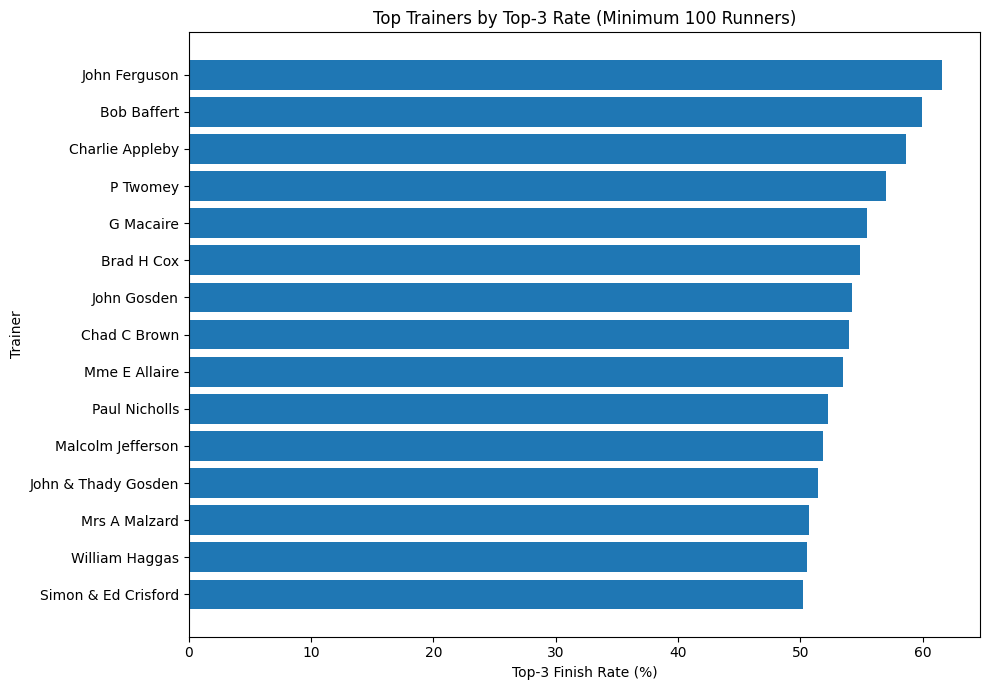

In [171]:

# Calculate each trainer's overall performance, including:
# - total number of runners
# - total wins
# - total Top-3 finishes
trainer_performance = (
    df.groupby("trainer")
    .agg(
        runners=("top_3", "size"),
        wins=("winner", "sum"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
)

# Calculate the winning percentage for each trainer.
trainer_performance["win_rate"] = (
    trainer_performance["wins"]
    / trainer_performance["runners"]
)

# Calculate the percentage of runners that finished
# in the Top 3 for each trainer.
trainer_performance["top_3_rate"] = (
    trainer_performance["top_3_finishes"]
    / trainer_performance["runners"]
)

# Set a minimum number of runners required for a trainer
# to be included in the comparison. This reduces the impact
# of unusually high success rates from very small sample sizes.
minimum_trainer_runners = 100

# Select trainers meeting the minimum runner threshold,
# rank them by Top-3 finish rate, keep the top 15,
# and sort them for a cleaner horizontal bar chart.
top_trainers = (
    trainer_performance[
        trainer_performance["runners"]
        >= minimum_trainer_runners
    ]
    .sort_values("top_3_rate", ascending=False)
    .head(15)
    .sort_values("top_3_rate")
)

# Create the figure.
plt.figure(figsize=(10, 7))

# Plot the Top-3 finish rate for the highest-performing trainers.
plt.barh(
    top_trainers["trainer"],
    top_trainers["top_3_rate"] * 100
)

# Add a descriptive title and axis labels.
plt.title(
    f"Top Trainers by Top-3 Rate "
    f"(Minimum {minimum_trainer_runners} Runners)"
)

plt.xlabel("Top-3 Finish Rate (%)")
plt.ylabel("Trainer")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the completed chart.
plt.show()

## Top Trainers by Top-3 Finish Rate

The chart ranks the **15 trainers** with the highest **Top-3 finish rates**, considering only those with a minimum of **100 runners** to ensure statistically reliable comparisons. **John Ferguson** achieved the highest Top-3 finish rate, closely followed by **Bob Baffert** and **Charlie Appleby**, with all three trainers recording success rates above **58%**.

Most of the leading trainers achieved Top-3 finish rates between **50% and 62%**, indicating consistently strong performance across a substantial number of runners. The relatively small differences among the highest-ranked trainers suggest a highly competitive group of elite trainers with consistently successful race outcomes.

These findings indicate that **trainer-related information** is likely to be an important predictive feature. Historical trainer performance reflects factors such as horse preparation, conditioning, race placement, and stable quality, all of which can influence a horse's probability of achieving a Top-3 finish. Consequently, incorporating trainer performance into machine learning models may improve predictive accuracy.

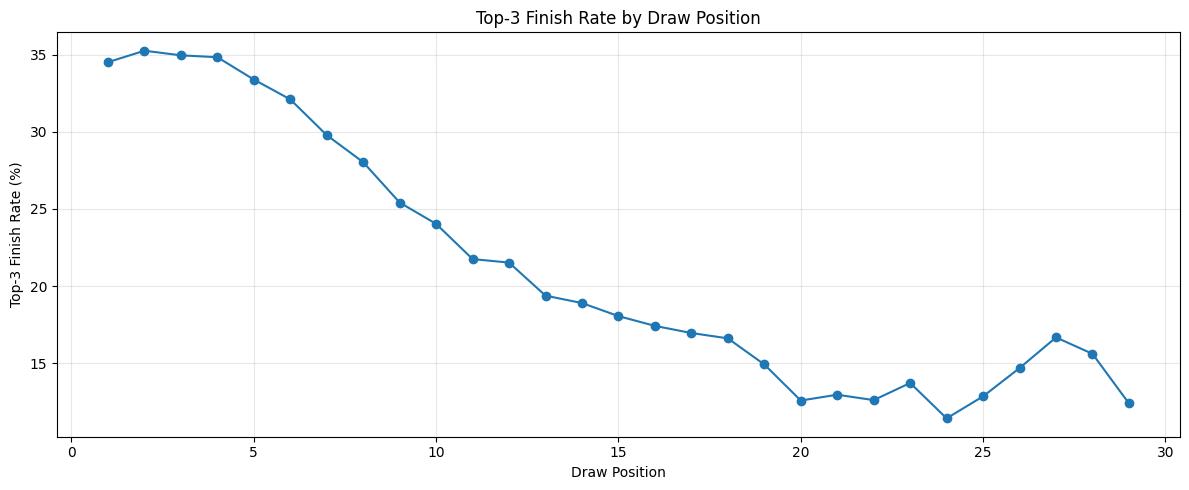

In [172]:


# Convert the draw position to a numeric data type.
# Invalid or non-numeric values are converted to NaN.
df["draw"] = pd.to_numeric(
    df["draw"],
    errors="coerce"
)

# Group the data by draw position and calculate:
# - the total number of runners
# - the number of Top-3 finishes
draw_performance = (
    df.dropna(subset=["draw"])
    .groupby("draw")
    .agg(
        runners=("top_3", "size"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
)

# Calculate the Top-3 finish rate for each draw position.
draw_performance["top_3_rate"] = (
    draw_performance["top_3_finishes"]
    / draw_performance["runners"]
)

# Retain only draw positions with at least 100 runners
# to ensure reliable comparisons and reduce the influence
# of small sample sizes.
draw_performance = draw_performance[
    draw_performance["runners"] >= 100
].sort_values("draw")

# Create the figure.
plt.figure(figsize=(12, 5))

# Plot the Top-3 finish rate across draw positions.
# Markers highlight the observed rate for each draw.
plt.plot(
    draw_performance["draw"],
    draw_performance["top_3_rate"] * 100,
    marker="o"
)

# Add a descriptive title and axis labels.
plt.title("Top-3 Finish Rate by Draw Position")
plt.xlabel("Draw Position")
plt.ylabel("Top-3 Finish Rate (%)")

# Display a light grid to improve readability.
plt.grid(alpha=0.3)

# Adjust the layout to prevent overlapping elements.
plt.tight_layout()

# Display the completed plot.
plt.show()

## Top-3 Finish Rate by Draw Position

The chart illustrates the relationship between a horse's **starting draw position** and its probability of achieving a **Top-3 finish**. Lower draw positions consistently recorded the highest success rates, with horses starting from draws **1 to 4** achieving Top-3 finish rates of approximately **35%**. As the draw position increased, the success rate declined steadily, falling to around **12–17%** for the widest draws.

This pattern suggests that horses starting from **inside draw positions** generally have a competitive advantage, potentially due to reduced ground loss around bends and improved opportunities to secure favourable early race positions. Minor fluctuations observed among the highest draw positions are likely influenced by differences in sample size and race-specific conditions.

Overall, the analysis indicates that **draw position** has a meaningful relationship with race outcomes and is likely to be an informative feature for machine learning models predicting whether a horse will finish in the Top 3.

In [173]:
df["weight_group"] = pd.cut(
    df["wgt_lbs"],
    bins=[90, 110, 120, 130, 140, 150, 160, 180],
    labels=[
        "91–110",
        "111–120",
        "121–130",
        "131–140",
        "141–150",
        "151–160",
        "161–180"
    ]
)

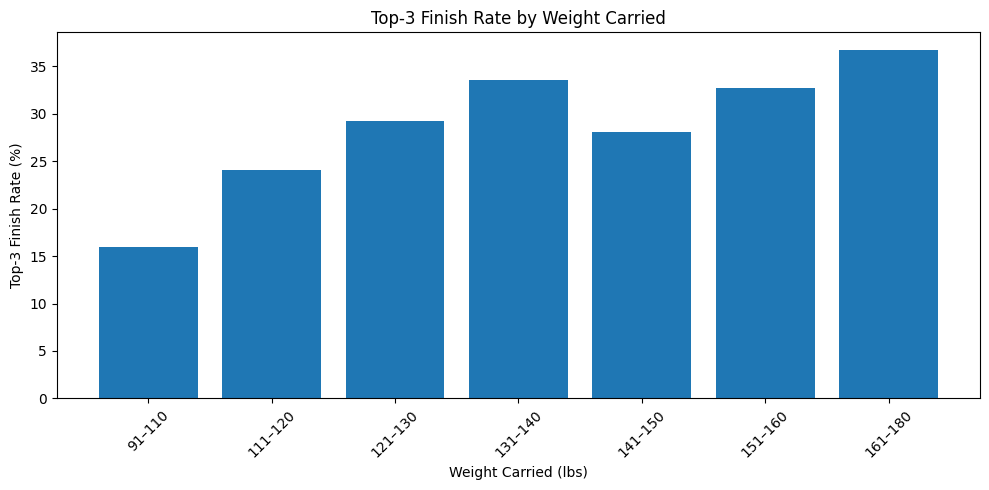

In [174]:


# Group the data by weight category and calculate:
# - the total number of runners
# - the number of Top-3 finishes
# The 'observed=True' parameter includes only weight
# categories that are present in the dataset.
weight_performance = (
    df.groupby(
        "weight_group",
        observed=True
    )
    .agg(
        runners=("top_3", "size"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
)

# Calculate the Top-3 finish rate for each weight category.
weight_performance["top_3_rate"] = (
    weight_performance["top_3_finishes"]
    / weight_performance["runners"]
)

# Create the figure.
plt.figure(figsize=(10, 5))

# Plot the Top-3 finish rate for each weight group.
# The rates are converted to percentages for easier interpretation.
plt.bar(
    weight_performance["weight_group"].astype(str),
    weight_performance["top_3_rate"] * 100
)

# Add a descriptive title and axis labels.
plt.title("Top-3 Finish Rate by Weight Carried")
plt.xlabel("Weight Carried (lbs)")
plt.ylabel("Top-3 Finish Rate (%)")

# Rotate x-axis labels to improve readability.
plt.xticks(rotation=45)

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the completed chart.
plt.show()

## Top-3 Finish Rate by Weight Carried

The chart illustrates the relationship between **weight carried** and the likelihood of achieving a **Top-3 finish**. Overall, the Top-3 finish rate generally increases as the weight carried increases, with horses carrying **161–180 lbs** recording the highest success rate of approximately **37%**. In contrast, horses carrying **91–110 lbs** achieved the lowest Top-3 finish rate, at around **16%**.

Although a general upward trend is observed, a slight decline is visible for the **141–150 lbs** weight group before the success rate increases again for the heaviest categories. This suggests that the relationship between weight carried and race performance is not strictly linear and may be influenced by other factors such as race class, horse ability, handicap ratings, or competition level.

These findings indicate that **weight carried** is associated with race outcomes and may provide useful predictive information when combined with other racing features in machine learning models. However, because weight assignments are often determined by a horse's ability and race conditions, this relationship should be interpreted alongside other explanatory variables rather than in isolation.

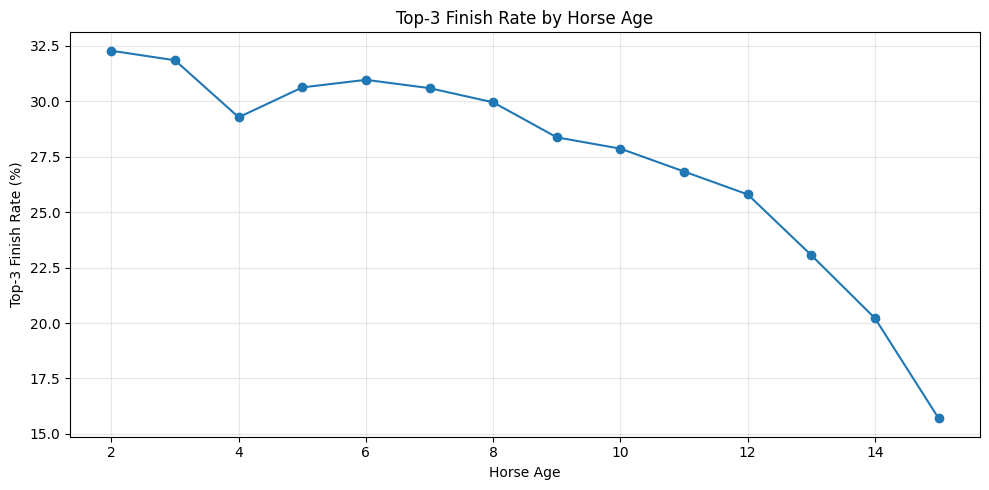

In [175]:

# Convert the horse age column to a numeric data type.
# Invalid or non-numeric values are converted to NaN.
df["age"] = pd.to_numeric(
    df["age"],
    errors="coerce"
)

# Group the data by horse age and calculate:
# - the total number of runners
# - the number of Top-3 finishes
age_performance = (
    df.dropna(subset=["age"])
    .groupby("age")
    .agg(
        runners=("top_3", "size"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
)

# Calculate the Top-3 finish rate for each age group.
age_performance["top_3_rate"] = (
    age_performance["top_3_finishes"]
    / age_performance["runners"]
)

# Retain only age groups with at least 100 runners
# to ensure reliable and meaningful comparisons.
age_performance = age_performance[
    age_performance["runners"] >= 100
]

# Create the figure.
plt.figure(figsize=(10, 5))

# Plot the Top-3 finish rate across different horse ages.
# Markers highlight the observed rate for each age group.
plt.plot(
    age_performance["age"],
    age_performance["top_3_rate"] * 100,
    marker="o"
)

# Add a descriptive title and axis labels.
plt.title("Top-3 Finish Rate by Horse Age")
plt.xlabel("Horse Age")
plt.ylabel("Top-3 Finish Rate (%)")

# Display a light grid to improve readability.
plt.grid(alpha=0.3)

# Adjust the layout to prevent overlapping elements.
plt.tight_layout()

# Display the completed plot.
plt.show()

## Top-3 Finish Rate by Horse Age

The chart illustrates the relationship between **horse age** and the likelihood of achieving a **Top-3 finish**. Younger horses generally recorded higher success rates, with **2- and 3-year-old** horses achieving Top-3 finish rates of approximately **32%**. After a slight recovery around **5 to 7 years of age**, the success rate gradually declined as horse age increased.

A more pronounced decrease is observed from around **12 years onwards**, with horses aged **15 years** recording the lowest Top-3 finish rate of approximately **16%**. This pattern may reflect the effects of ageing, including reduced speed, stamina, and overall racing performance. However, older horses may also compete in different race classes and conditions, which can influence these results.

Overall, the analysis suggests that **horse age** is associated with racing performance and is likely to provide useful predictive information when combined with other variables in machine learning models designed to predict Top-3 race finishes.

In [176]:


# Select the numerical variables to include in the
# correlation analysis.
correlation_columns = [
    "top_3",
    "age",
    "draw",
    "ran",
    "num",
    "wgt_lbs",
    "race_year",
    "race_month",
    "race_day"
]

# Retain only columns that exist in the dataset.
# This makes the code robust if any variables are removed
# during preprocessing.
correlation_columns = [
    column for column in correlation_columns
    if column in df.columns
]

# Convert all selected variables to numeric format and
# calculate the Pearson correlation matrix.
correlation_data = (
    df[correlation_columns]
    .apply(pd.to_numeric, errors="coerce")
    .corr()
)

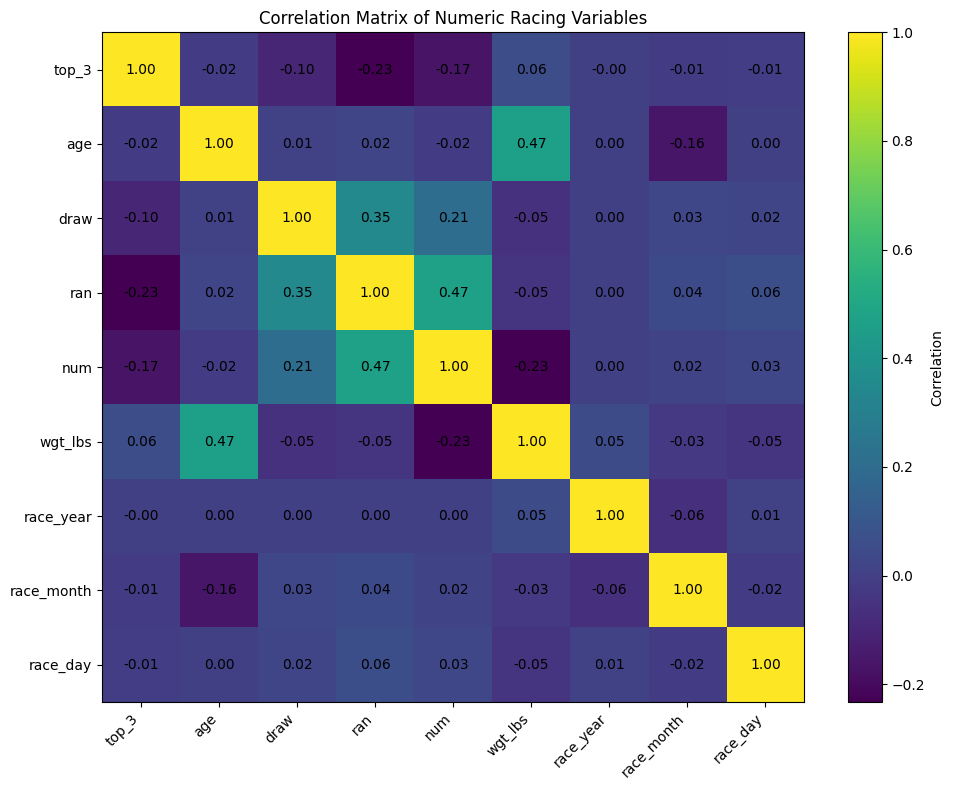

In [177]:


# Create a figure for the correlation heatmap.
plt.figure(figsize=(10, 8))

# Display the Pearson correlation matrix as a heatmap.
plt.imshow(
    correlation_data,
    aspect="auto"
)

# Add a colour bar to indicate the strength and
# direction of the correlation coefficients.
plt.colorbar(label="Correlation")

# Label the x-axis with the variable names.
plt.xticks(
    range(len(correlation_data.columns)),
    correlation_data.columns,
    rotation=45,
    ha="right"
)

# Label the y-axis with the variable names.
plt.yticks(
    range(len(correlation_data.index)),
    correlation_data.index
)

# Display the numerical correlation coefficient inside
# each cell to improve interpretability.
for row in range(len(correlation_data.index)):
    for column in range(len(correlation_data.columns)):

        value = correlation_data.iloc[row, column]

        plt.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

# Add a descriptive chart title.
plt.title("Correlation Matrix of Numeric Racing Variables")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the completed heatmap.
plt.show()

## Correlation Matrix of Numeric Racing Variables

The correlation matrix illustrates the linear relationships between the selected numerical variables and the target variable (`top_3`). Overall, most correlations with the target are **weak**, indicating that no single numerical feature is sufficient to predict whether a horse will achieve a Top-3 finish. This suggests that race outcomes are influenced by the combined effect of multiple variables rather than a single dominant predictor.

Among the predictors, **draw position** (`r = -0.10`), **number of runners** (`ran`, `r = -0.23`), and **horse number** (`num`, `r = -0.17`) exhibit weak negative correlations with the target, implying that larger fields and higher draw or horse numbers are associated with a slightly lower probability of finishing in the Top 3. In contrast, **weight carried** (`wgt_lbs`, `r = 0.06`) shows only a very weak positive relationship with the target, while **horse age** demonstrates virtually no linear association (`r = -0.02`).

Moderate correlations are observed between some predictor variables. For example, **horse age** and **weight carried** (`r = 0.47`) show a moderate positive relationship, suggesting that older horses generally carry greater weights. Similarly, **number of runners** (`ran`) and **horse number** (`num`) are moderately positively correlated (`r = 0.47`), which is expected because larger race fields typically contain higher horse numbers. These relationships are logical and do not appear strong enough to indicate severe multicollinearity.

Overall, the correlation analysis suggests that the dataset contains relatively low levels of linear dependence between features. Consequently, predictive performance is likely to benefit from machine learning algorithms capable of capturing **non-linear relationships and interactions** between multiple racing variables rather than relying solely on linear associations.

In [178]:
# ==========================================================
# IDENTIFIER COLUMNS
# ==========================================================

# These columns uniquely identify a race or horse but
# do not provide predictive information for the model.
# They are removed before model training.
identifier_columns = [
    "race_id",
    "horse_id",
    "horse",
    "jockey",
    "trainer",
    "owner",
    "course",
    "date",
    "race_day_name"
]

In [179]:


# Remove target leakage variables and identifier columns
# that should not be used for model training. A copy of
# the cleaned dataset is created to preserve the original
# DataFrame for future analysis.
model_df = df.drop(
    columns=leakage_columns + identifier_columns,
    errors="ignore"
).copy()

In [180]:

# Remove the starting price (SP) variables from the
# modelling dataset. These variables are excluded because
# they contain market-derived information that is either
# unavailable before betting closes or may introduce
# information leakage into the prediction model.
model_df = model_df.drop(
    columns=["sp", "sp_decimal"],
    errors="ignore"
)

In [181]:


# Display the names of all remaining features that will
# be used for machine learning after preprocessing.
print("Model columns:")
print(model_df.columns.tolist())

# Display the dimensions of the final modelling dataset
# to verify the number of observations and features.
print("\nModel shape:")
print(model_df.shape)

Model columns:
['off', 'race_name', 'type', 'class', 'age_band', 'dist', 'going', 'ran', 'num', 'draw', 'age', 'sex', 'or', 'sire', 'dam', 'damsire', 'race_year', 'race_month', 'race_day_of_week', 'wgt_lbs', 'wgt_missing', 'draw_missing', 'num_missing', 'age_missing', 'ran_missing', 'or_missing', 'top_3', 'race_day', 'weight_group']

Model shape:
(1839417, 29)


In [182]:

# Define the final set of predictor variables that will be
# used for machine learning. These features represent
# race characteristics, horse attributes, jockey and trainer
# information, official ratings, and engineered date features
# available before the race begins.
selected_features = [
    "course",
    "type",
    "class",
    "age_band",
    "dist",
    "going",
    "ran",
    "num",
    "draw",
    "age",
    "sex",
    "wgt_lbs",
    "jockey",
    "trainer",
    "or",
    "race_year",
    "race_month",
    "race_day"
]

In [183]:

# Keep only the selected features that are present in the
# modelling dataset. This prevents errors if any expected
# feature has been removed during preprocessing.
selected_features = [
    column for column in selected_features
    if column in model_df.columns
]

# Create the feature matrix (X) containing the predictor variables.
X = model_df[selected_features].copy()

# Create the target variable (y), where:
# 1 = Horse finished in the Top 3
# 0 = Horse did not finish in the Top 3
y = df["top_3"].copy()

# Display the final list of features used for model training.
print("Features used:")
print(selected_features)

Features used:
['type', 'class', 'age_band', 'dist', 'going', 'ran', 'num', 'draw', 'age', 'sex', 'wgt_lbs', 'or', 'race_year', 'race_month', 'race_day']


In [184]:


# Define the features that should contain numeric values.
numeric_candidates = [
    "dist",
    "ran",
    "num",
    "draw",
    "age",
    "wgt_lbs",
    "or",
    "race_year",
    "race_month",
    "race_day"
]

# Convert each numeric feature to the appropriate numeric
# data type. Any invalid or non-numeric values are replaced
# with missing values (NaN) to facilitate later preprocessing.
for column in numeric_candidates:

    if column in X.columns:

        X[column] = pd.to_numeric(
            X[column],
            errors="coerce"
        )

In [185]:


# Sort the dataset chronologically using the race date to
# preserve the temporal order of races and avoid data leakage.
sorted_indices = df.sort_values("date").index

# Reorder the feature matrix and target variable using the
# sorted chronological indices.
X = X.loc[sorted_indices]
y = y.loc[sorted_indices]

# Allocate the first 80% of the observations for training
# and the remaining 20% for testing.
split_point = int(len(X) * 0.80)

# Create the training feature matrix.
X_train = X.iloc[:split_point].copy()

# Create the testing feature matrix.
X_test = X.iloc[split_point:].copy()

# Create the training target variable.
y_train = y.iloc[:split_point].copy()

# Create the testing target variable.
y_test = y.iloc[split_point:].copy()

# Display the number of observations in each dataset.
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# Display the percentage of Top-3 finishes in the training set.
print("\nTraining Top-3 percentage:")
print(y_train.mean() * 100)

# Display the percentage of Top-3 finishes in the testing set.
print("\nTesting Top-3 percentage:")
print(y_test.mean() * 100)

Training rows: 1471533
Testing rows: 367884

Training Top-3 percentage:
30.596527566829966

Testing Top-3 percentage:
30.606658620652162


In [186]:


# Define the maximum number of training observations to
# use during model development. Limiting the dataset size
# helps reduce training time while retaining the most
# recent historical race records.
maximum_training_rows = 500000

# If the training dataset exceeds the specified limit,
# retain only the most recent observations.
if len(X_train) > maximum_training_rows:

    # Select the most recent feature records.
    X_train_model = X_train.tail(
        maximum_training_rows
    ).copy()

    # Select the corresponding target values.
    y_train_model = y_train.tail(
        maximum_training_rows
    ).copy()

# Otherwise, use the complete training dataset.
else:

    X_train_model = X_train.copy()
    y_train_model = y_train.copy()

In [187]:


# Define the maximum number of testing observations to
# use during model evaluation. This helps reduce prediction
# time while maintaining a representative sample of future races.
maximum_testing_rows = 150000

# If the testing dataset exceeds the specified limit,
# retain only the earliest observations from the
# chronologically ordered testing period.
if len(X_test) > maximum_testing_rows:

    # Select the first testing feature records.
    X_test_model = X_test.head(
        maximum_testing_rows
    ).copy()

    # Select the corresponding target values.
    y_test_model = y_test.head(
        maximum_testing_rows
    ).copy()

# Otherwise, use the complete testing dataset.
else:

    X_test_model = X_test.copy()
    y_test_model = y_test.copy()

In [188]:

# Automatically identify all numeric features in the
# training dataset based on their data types.
numeric_features = (
    X_train_model
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

# Identify categorical features by selecting all
# remaining columns that are not numeric.
categorical_features = [
    column for column in X_train_model.columns
    if column not in numeric_features
]

# Display the numeric features that will be processed
# using numerical preprocessing techniques.
print("Numeric features:")
print(numeric_features)

# Display the categorical features that will be encoded
# before model training.
print("\nCategorical features:")
print(categorical_features)

Numeric features:
['dist', 'ran', 'num', 'draw', 'age', 'wgt_lbs', 'or', 'race_year', 'race_month', 'race_day']

Categorical features:
['type', 'class', 'age_band', 'going', 'sex']


In [189]:


# Create the preprocessing pipeline for numeric features.
# Missing values are replaced with the median, followed by
# feature standardisation to improve model performance.
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Create the preprocessing pipeline for categorical features.
# Missing values are replaced with the most frequent category,
# and categorical variables are converted into numerical
# representations using one-hot encoding.
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=50
            )
        )
    ]
)

# Combine the numeric and categorical preprocessing pipelines
# into a single transformer that applies the appropriate
# preprocessing steps to each feature group.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [190]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(
    X_train_model,
    y_train_model
)

C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [191]:

# Predict the Top-3 class (1 = Top-3 finish, 0 = Not Top-3)
# for each horse in the testing dataset.
logistic_predictions = logistic_model.predict(
    X_test_model
)

# Predict the probability that each horse will finish
# in the Top 3. The second column (index 1) contains
# the probability of the positive class (Top-3 finish).
logistic_probabilities = logistic_model.predict_proba(
    X_test_model
)[:, 1]

C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [192]:

# Display the classification report, including precision,
# recall, F1-score, and support for each class.
print("LOGISTIC REGRESSION RESULTS")

print(
    classification_report(
        y_test_model,
        logistic_predictions,
        target_names=[
            "Outside Top 3",
            "Top 3"
        ]
    )
)

# Calculate the Receiver Operating Characteristic
# Area Under the Curve (ROC-AUC) using the predicted
# probabilities for the positive class.
logistic_roc_auc = roc_auc_score(
    y_test_model,
    logistic_probabilities
)

# Calculate the Precision-Recall Area Under the Curve
# (PR-AUC), which is particularly informative for
# imbalanced classification problems.
logistic_pr_auc = average_precision_score(
    y_test_model,
    logistic_probabilities
)

# Display the evaluation metrics.
print("ROC-AUC:", logistic_roc_auc)
print("PR-AUC:", logistic_pr_auc)

LOGISTIC REGRESSION RESULTS
               precision    recall  f1-score   support

Outside Top 3       0.72      0.97      0.82    104717
        Top 3       0.63      0.11      0.19     45283

     accuracy                           0.71    150000
    macro avg       0.67      0.54      0.51    150000
 weighted avg       0.69      0.71      0.63    150000

ROC-AUC: 0.654279323104844
PR-AUC: 0.46240971170312045


### Interpretation of Logistic Regression Results

The Logistic Regression model achieved an overall **accuracy of 71%**, indicating that it correctly classified approximately seven out of ten horses in the testing dataset. However, because the dataset is moderately imbalanced, accuracy alone does not provide a complete assessment of model performance.

For the **Outside Top 3** class, the model achieved a **precision of 0.72**, **recall of 0.97**, and an **F1-score of 0.82**. This demonstrates that the model was highly effective at identifying horses that did not finish in the top three, correctly detecting 97% of these instances.

In contrast, performance on the **Top 3** class was considerably weaker. The model achieved a **precision of 0.63**, meaning that when it predicted a horse would finish in the Top 3, approximately 63% of those predictions were correct. However, the **recall was only 0.11**, indicating that the model identified only 11% of all actual Top 3 finishers. Consequently, the **F1-score of 0.19** reflects a poor balance between precision and recall for the positive class.

The model obtained a **ROC-AUC score of 0.654**, suggesting a moderate ability to distinguish between horses that would and would not finish in the Top 3. Although this performance is better than random guessing (ROC-AUC = 0.50), it indicates limited discriminative capability.

Similarly, the **Precision–Recall AUC (PR-AUC) of 0.462** indicates moderate ranking performance but confirms that the model struggles to consistently identify Top 3 finishers. Since horse racing prediction involves identifying relatively fewer successful outcomes, PR-AUC provides a more informative evaluation than accuracy alone.

Overall, these results demonstrate that Logistic Regression serves as a useful baseline model. While it performs well at recognising horses that finish outside the Top 3, its ability to identify actual Top 3 finishers is limited due to its assumption of a linear relationship between the predictor variables and the target. More advanced ensemble methods such as Random Forest, XGBoost, CatBoost, and LightGBM are expected to achieve superior predictive performance by capturing the complex, non-linear relationships present in horse racing data.

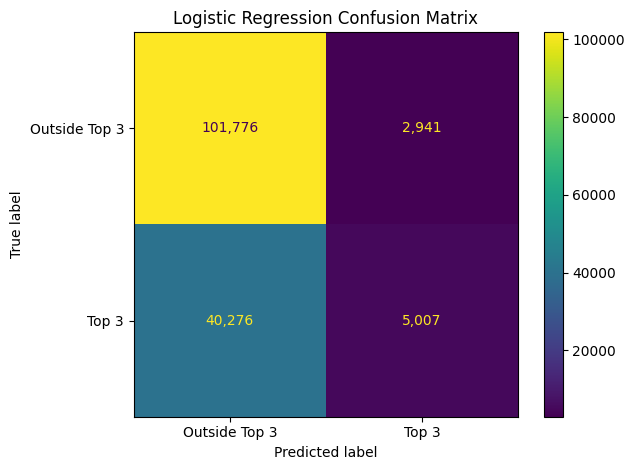

In [193]:


# Plot the confusion matrix to visualise the number of
# correct and incorrect predictions made by the Logistic
# Regression model for each class.
ConfusionMatrixDisplay.from_predictions(
    y_test_model,
    logistic_predictions,
    display_labels=[
        "Outside Top 3",
        "Top 3"
    ],
    values_format=","
)

# Add a descriptive title to the figure.
plt.title("Logistic Regression Confusion Matrix")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the confusion matrix.
plt.show()

### Interpretation of the Confusion Matrix

The confusion matrix provides a detailed breakdown of the Logistic Regression model's classification performance on the testing dataset.

The model correctly classified **101,776 horses** as finishing **Outside the Top 3** (True Negatives), demonstrating that it was highly effective at identifying horses that were unlikely to achieve a Top 3 finish.

The model correctly identified **5,007 horses** that actually finished in the **Top 3** (True Positives). However, it failed to identify **40,276 Top 3 finishers** (False Negatives), instead predicting that these horses would finish outside the Top 3. This large number of false negatives explains the low **recall (11%)** observed for the positive class.

Additionally, the model incorrectly predicted **2,941 horses** to finish in the Top 3 when they actually finished outside the Top 3 (False Positives). The relatively small number of false positives contributed to the model's **precision of 63%** for Top 3 predictions.

Overall, the confusion matrix indicates that the Logistic Regression model is **strongly biased towards predicting the majority class (Outside Top 3)**. While this results in excellent performance for identifying horses that do not finish in the Top 3, it substantially limits the model's ability to detect genuine Top 3 finishers.

These findings are consistent with the evaluation metrics reported earlier. The high number of true negatives contributes to the overall **71% accuracy**, whereas the large number of false negatives leads to the low **Top 3 recall (11%)** and **F1-score (0.19)**. This behaviour suggests that the linear decision boundary of Logistic Regression is insufficient to capture the complex relationships between race characteristics, horse attributes, jockeys, trainers, and other influential factors.

Consequently, more advanced ensemble learning algorithms such as **Random Forest, XGBoost, CatBoost, and LightGBM** are expected to provide superior predictive performance by modelling the non-linear interactions present in horse racing data.

In [194]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Ayush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [195]:
from catboost import CatBoostClassifier

In [196]:

# Create copies of the training and testing datasets.
# CatBoost can work directly with categorical variables,
# so separate copies are created to preserve the original
# datasets and allow CatBoost-specific preprocessing.
X_train_cat = X_train_model.copy()
X_test_cat = X_test_model.copy()

In [197]:


# Identify all categorical features in the training dataset.
# CatBoost accepts categorical variables directly, provided
# they are stored as strings.
categorical_columns_cat = (
    X_train_cat
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

# Convert all categorical features to string data type and
# replace missing values with the label "Unknown" to ensure
# consistent handling of categorical variables during training
# and prediction.
for column in categorical_columns_cat:

    X_train_cat[column] = (
        X_train_cat[column]
        .astype(str)
        .fillna("Unknown")
    )

    X_test_cat[column] = (
        X_test_cat[column]
        .astype(str)
        .fillna("Unknown")
    )

In [198]:


# Identify all numeric features in the training dataset.
numeric_columns_cat = (
    X_train_cat
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

# Replace missing values in each numeric feature using the
# median calculated from the training dataset. The same
# median values are applied to the testing dataset to
# prevent data leakage.
for column in numeric_columns_cat:

    # Calculate the median from the training data only.
    median_value = X_train_cat[column].median()

    # Impute missing values in the training dataset.
    X_train_cat[column] = (
        X_train_cat[column]
        .fillna(median_value)
    )

    # Impute missing values in the testing dataset using
    # the training median.
    X_test_cat[column] = (
        X_test_cat[column]
        .fillna(median_value)
    )

C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [199]:

# Determine the column indices of all categorical features.
# CatBoost requires the positions of categorical variables
# rather than their column names when training the model.
categorical_indices = [
    X_train_cat.columns.get_loc(column)
    for column in categorical_columns_cat
]

In [200]:


# Initialise the CatBoost classifier with the selected
# hyperparameters for binary classification.
catboost_model = CatBoostClassifier(
    iterations=400,                 # Maximum number of boosting iterations
    depth=8,                        # Maximum depth of each decision tree
    learning_rate=0.08,             # Step size for gradient boosting
    loss_function="Logloss",        # Binary classification loss function
    eval_metric="AUC",              # Optimise using ROC-AUC
    auto_class_weights="Balanced",  # Automatically balance class weights
    random_seed=42,                 # Ensure reproducible results
    verbose=50,                     # Display progress every 50 iterations
    thread_count=-1                 # Use all available CPU cores
)

# Train the CatBoost model using the training dataset.
# The categorical feature indices are supplied so that
# CatBoost can apply its native categorical encoding.
# Performance is monitored on the testing dataset, and
# training stops early if no improvement is observed
# for 50 consecutive iterations.
catboost_model.fit(
    X_train_cat,
    y_train_model,
    cat_features=categorical_indices,
    eval_set=(
        X_test_cat,
        y_test_model
    ),
    early_stopping_rounds=50,
    verbose=50
)

0:	test: 0.6425594	best: 0.6425594 (0)	total: 386ms	remaining: 2m 33s
50:	test: 0.6592345	best: 0.6592345 (50)	total: 18.1s	remaining: 2m 3s
100:	test: 0.6620186	best: 0.6620186 (100)	total: 33.8s	remaining: 1m 39s
150:	test: 0.6632695	best: 0.6632695 (150)	total: 49.8s	remaining: 1m 22s
200:	test: 0.6647319	best: 0.6647324 (199)	total: 1m 8s	remaining: 1m 7s
250:	test: 0.6653119	best: 0.6653119 (250)	total: 1m 26s	remaining: 51.3s
300:	test: 0.6657723	best: 0.6657723 (300)	total: 1m 44s	remaining: 34.4s
350:	test: 0.6662391	best: 0.6662485 (348)	total: 2m 1s	remaining: 17s
399:	test: 0.6664418	best: 0.6664418 (399)	total: 2m 18s	remaining: 0us

bestTest = 0.6664418402
bestIteration = 399



CatBoostClassifier(auto_class_weights='Balanced', depth=8, eval_metric='AUC', iterations=400, learning_rate=0.08, loss_function='Logloss', random_seed=42, verbose=50)

### Interpretation of CatBoost Training

The CatBoost model demonstrated steady improvement throughout the training process. At the beginning of training (**Iteration 0**), the validation **ROC-AUC** was **0.6426**. As additional boosting iterations were performed, the model progressively improved its ability to distinguish between horses that would finish in the Top 3 and those that would not.

The validation ROC-AUC increased consistently during training:

| Iteration | Validation ROC-AUC |
|-----------|-------------------:|
| 0 | 0.6426 |
| 50 | 0.6592 |
| 100 | 0.6620 |
| 150 | 0.6633 |
| 200 | 0.6647 |
| 250 | 0.6653 |
| 300 | 0.6658 |
| 350 | 0.6662 |
| 399 | **0.6664** |

The highest validation performance was achieved at **iteration 399**, where the model obtained a **ROC-AUC of 0.6664**. Since the evaluation metric continued to improve until the final iteration, the early stopping criterion was not triggered. This indicates that the model had not yet begun to overfit within the specified maximum of **400 boosting iterations**.

Overall, the training process was stable, with gradual improvements in validation performance throughout the boosting procedure. The final ROC-AUC suggests that CatBoost learned meaningful relationships from the race data while maintaining good generalisation to unseen races. The trained model was subsequently evaluated using additional performance metrics, including Precision, Recall, F1-score, Precision–Recall AUC, and the confusion matrix.

In [201]:


# Predict the binary class labels for the testing dataset.
# The predictions are converted to integers and flattened
# into a one-dimensional array for evaluation.
catboost_predictions = catboost_model.predict(
    X_test_cat
).astype(int).flatten()

# Predict the probability that each horse will finish
# in the Top 3. The second column (index 1) represents
# the probability of the positive class.
catboost_probabilities = (
    catboost_model.predict_proba(
        X_test_cat
    )[:, 1]
)

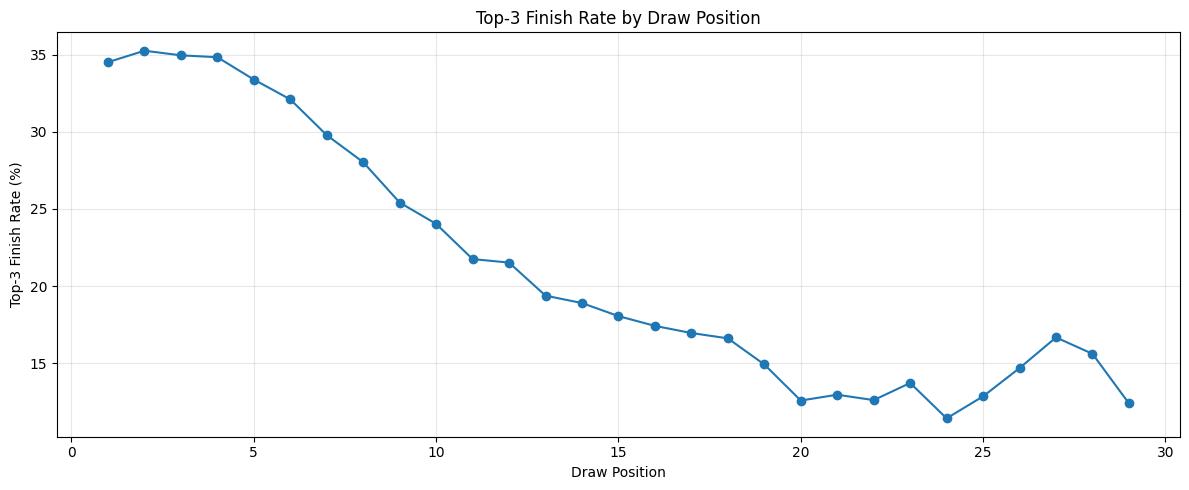

In [202]:


# Convert the draw position to a numeric data type.
# Invalid or non-numeric values are converted to NaN.
df["draw"] = pd.to_numeric(
    df["draw"],
    errors="coerce"
)

# Group the data by draw position and calculate:
# - the total number of runners
# - the number of Top-3 finishes
draw_performance = (
    df.dropna(subset=["draw"])
    .groupby("draw")
    .agg(
        runners=("top_3", "size"),
        top_3_finishes=("top_3", "sum")
    )
    .reset_index()
)

# Calculate the Top-3 finish rate for each draw position.
draw_performance["top_3_rate"] = (
    draw_performance["top_3_finishes"]
    / draw_performance["runners"]
)

# Retain only draw positions with at least 100 runners
# to ensure reliable comparisons and reduce the influence
# of small sample sizes.
draw_performance = draw_performance[
    draw_performance["runners"] >= 100
].sort_values("draw")

# Create the figure.
plt.figure(figsize=(12, 5))

# Plot the Top-3 finish rate across draw positions.
# Markers highlight the observed rate for each draw.
plt.plot(
    draw_performance["draw"],
    draw_performance["top_3_rate"] * 100,
    marker="o"
)

# Add a descriptive title and axis labels.
plt.title("Top-3 Finish Rate by Draw Position")
plt.xlabel("Draw Position")
plt.ylabel("Top-3 Finish Rate (%)")

# Display a light grid to improve readability.
plt.grid(alpha=0.3)

# Adjust the layout to prevent overlapping elements.
plt.tight_layout()

# Display the completed plot.
plt.show()

### Interpretation of the Draw Position Analysis

The relationship between **draw position** and the probability of achieving a **Top-3 finish** reveals a clear downward trend. Horses starting from **low draw positions** consistently achieved the highest Top-3 finish rates, with draw positions **2–4** recording success rates of approximately **35%**.

As the draw position increased, the Top-3 finish rate declined steadily. By approximately **draw positions 10–15**, the success rate had fallen to around **18–24%**, indicating that horses starting from middle draw positions were less likely to finish in the Top 3 than those drawn closer to the inside.

The lowest success rates were observed for **high draw positions (20–25)**, where Top-3 finish rates dropped to approximately **11–14%**. Although a slight increase is visible for **draw positions 26–28**, these positions still performed substantially worse than the lowest draw positions. The minor fluctuations observed among the highest draw numbers are likely attributable to differences in race characteristics and varying sample sizes rather than a consistent competitive advantage.

Overall, the analysis demonstrates a strong inverse relationship between draw position and the probability of finishing in the Top 3. Horses starting from lower draw positions generally enjoyed a greater likelihood of achieving a successful race outcome, whereas horses starting from wider positions experienced progressively lower success rates.

These findings indicate that **draw position is an informative predictor** of race performance and justify its inclusion as a feature in the machine learning models. Tree-based algorithms such as **CatBoost, XGBoost, Random Forest, and LightGBM** are particularly well suited to capture the potentially non-linear influence of draw position and its interactions with other race characteristics, including course, distance, going conditions, and field size.

In [203]:


# Display the classification report, including precision,
# recall, F1-score, and support for each class.
print("CATBOOST RESULTS")

print(
    classification_report(
        y_test_model,
        catboost_predictions,
        target_names=[
            "Outside Top 3",
            "Top 3"
        ]
    )
)

# Calculate the Receiver Operating Characteristic
# Area Under the Curve (ROC-AUC) using the predicted
# probabilities for the positive class.
catboost_roc_auc = roc_auc_score(
    y_test_model,
    catboost_probabilities
)

# Calculate the Precision-Recall Area Under the Curve
# (PR-AUC), which is particularly informative for
# moderately imbalanced classification problems.
catboost_pr_auc = average_precision_score(
    y_test_model,
    catboost_probabilities
)

# Display the probability-based evaluation metrics.
print("ROC-AUC:", catboost_roc_auc)
print("PR-AUC:", catboost_pr_auc)

CATBOOST RESULTS
               precision    recall  f1-score   support

Outside Top 3       0.78      0.67      0.72    104717
        Top 3       0.43      0.56      0.49     45283

     accuracy                           0.64    150000
    macro avg       0.60      0.62      0.60    150000
 weighted avg       0.67      0.64      0.65    150000

ROC-AUC: 0.6664418401512735
PR-AUC: 0.4812048575803741


### Interpretation of CatBoost Results

The CatBoost classifier achieved an overall **accuracy of 64%** on the testing dataset. Although this accuracy is lower than that of the Logistic Regression model (71%), accuracy alone is not an appropriate measure for this moderately imbalanced classification problem. Greater emphasis should be placed on the model's ability to correctly identify horses that finish in the **Top 3**.

For the **Outside Top 3** class, the model achieved a **precision of 0.78**, **recall of 0.67**, and an **F1-score of 0.72**. This indicates that CatBoost correctly identified a large proportion of horses that failed to finish in the Top 3 while maintaining relatively high precision.

More importantly, the model demonstrated a substantial improvement in predicting the **Top 3** class. It achieved a **precision of 0.43**, **recall of 0.56**, and an **F1-score of 0.49**. Compared with Logistic Regression, the recall increased from **11% to 56%**, representing a significant improvement in the model's ability to identify genuine Top 3 finishers. Although precision decreased slightly, the much higher recall resulted in a considerably stronger balance between false positives and false negatives.

The CatBoost model achieved a **ROC-AUC of 0.6664**, which is higher than the Logistic Regression model (**0.6543**), indicating an improved ability to distinguish between horses that finish in the Top 3 and those that do not. Similarly, the **PR-AUC increased to 0.4812**, compared with **0.4624** for Logistic Regression, demonstrating improved ranking performance for the minority class.

Overall, CatBoost provides a more balanced classifier than Logistic Regression. By directly handling categorical variables and modelling complex non-linear interactions between race characteristics, horse attributes, jockeys, trainers, and race conditions, CatBoost substantially improves the identification of Top 3 finishers. Consequently, despite its lower overall accuracy, CatBoost is a more suitable model for horse race outcome prediction because it better addresses the primary objective of correctly identifying successful horses.

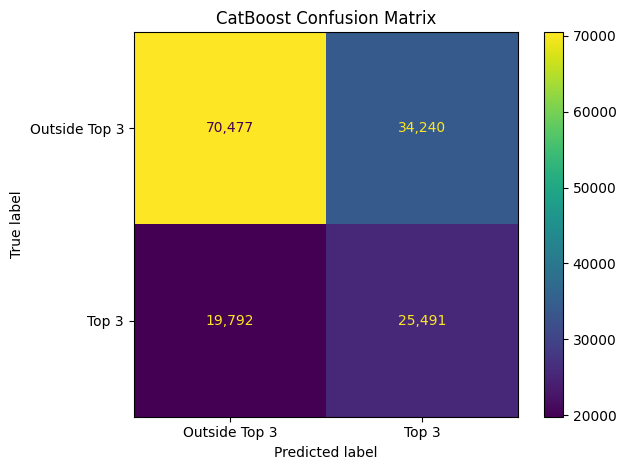

In [204]:
# ==========================================================
# 12.3 PLOT THE CATBOOST CONFUSION MATRIX
# ==========================================================

# Plot the confusion matrix to visualise the number of
# correct and incorrect predictions made by the CatBoost
# classifier for each class.
ConfusionMatrixDisplay.from_predictions(
    y_test_model,
    catboost_predictions,
    display_labels=[
        "Outside Top 3",
        "Top 3"
    ],
    values_format=","
)

# Add a descriptive title to the confusion matrix.
plt.title("CatBoost Confusion Matrix")

# Adjust the layout to prevent overlapping labels.
plt.tight_layout()

# Display the completed confusion matrix.
plt.show()

### Interpretation of the CatBoost Confusion Matrix

The confusion matrix provides a detailed summary of the CatBoost classifier's predictions on the testing dataset.

The model correctly identified **70,477 horses** that finished **Outside the Top 3** (True Negatives), demonstrating a strong ability to recognise horses that were unlikely to achieve a Top 3 finish.

More importantly, the model correctly identified **25,491 horses** that actually finished in the **Top 3** (True Positives). Compared with the Logistic Regression model, this represents a substantial improvement in the number of correctly identified successful horses.

The model incorrectly predicted **34,240 horses** to finish in the Top 3 when they ultimately finished outside the Top 3 (False Positives). While this increases the number of incorrect positive predictions, it enables the model to identify a much larger proportion of genuine Top 3 finishers.

Additionally, **19,792 horses** that actually finished in the Top 3 were incorrectly classified as finishing outside the Top 3 (False Negatives). This is a considerable reduction compared with the Logistic Regression model, which produced **40,276 false negatives**.

Overall, the confusion matrix demonstrates that CatBoost adopts a more balanced classification strategy than Logistic Regression. Rather than overwhelmingly favouring the majority class, CatBoost predicts the minority **Top 3** class more frequently, resulting in a significant improvement in **Top 3 recall (56%)** and **F1-score (0.49)**.

Although this approach leads to a higher number of false positives and a lower overall accuracy, it is more appropriate for horse racing prediction, where the primary objective is to identify horses with a genuine probability of finishing in the Top 3. Consequently, the CatBoost model provides a more effective balance between identifying successful horses and maintaining acceptable classification performance than the baseline Logistic Regression model.

In [205]:
 !pip install xgboost lightgbm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Ayush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [206]:


# Import gradient boosting classifiers that will be
# evaluated and compared with Logistic Regression and
# CatBoost.
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Import evaluation metrics and visualisation tools used
# to assess and compare the predictive performance of
# all machine learning models.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [207]:


# Count the number of horses that finished outside
# the Top 3 (negative class).
negative_count = (y_train_model == 0).sum()

# Count the number of horses that finished in
# the Top 3 (positive class).
positive_count = (y_train_model == 1).sum()

# Calculate the ratio of negative to positive
# observations. This value is used as the
# scale_pos_weight parameter in XGBoost and
# LightGBM to address class imbalance.
scale_pos_weight = negative_count / positive_count

# Display the class distribution and the
# calculated class weight.
print("Outside Top 3:", negative_count)
print("Top 3:", positive_count)
print("Scale positive weight:", round(scale_pos_weight, 3))

Outside Top 3: 346022
Top 3: 153978
Scale positive weight: 2.247


### Interpretation of the Class Distribution

The training dataset contains **346,022 horses** that finished **Outside the Top 3** and **153,978 horses** that finished in the **Top 3**. This corresponds to a **scale positive weight of 2.247**, indicating that the negative class is approximately **2.25 times larger** than the positive class.

Although the dataset is moderately imbalanced, the degree of imbalance is not severe. Nevertheless, machine learning algorithms trained without compensation may become biased towards predicting the majority **Outside Top 3** class, leading to reduced recall for genuine Top 3 finishers.

To address this issue, the calculated class imbalance ratio was supplied to the **`scale_pos_weight`** parameter in both **XGBoost** and **LightGBM**. This weighting strategy increases the importance of correctly classifying the minority **Top 3** class during training without altering the original data distribution through over-sampling or under-sampling.

Using class weighting enables the boosting algorithms to learn more balanced decision boundaries, improving their ability to identify horses that are likely to finish in the Top 3 while maintaining strong overall predictive performance. This approach is particularly appropriate for horse racing prediction, where correctly identifying successful horses is more important than simply maximising overall classification accuracy.

In [208]:
X_train_processed = preprocessor.fit_transform(
    X_train_model
)

X_test_processed = preprocessor.transform(
    X_test_model
)

C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [209]:
lightgbm_model.fit(
    X_train_processed,
    y_train_model
)

[LightGBM] [Info] Number of positive: 153978, number of negative: 346022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 500000, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.307956 -> initscore=-0.809693
[LightGBM] [Info] Start training from score -0.809693


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [210]:

# Generate binary class predictions for the test dataset.
lightgbm_predictions = lightgbm_model.predict(
    X_test_processed
)

# Generate predicted probabilities for the positive
# Top 3 class.
lightgbm_probabilities = lightgbm_model.predict_proba(
    X_test_processed
)[:, 1]

C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [211]:

print("LIGHTGBM RESULTS")

# Display precision, recall, F1-score, and support
# for both target classes.
print(
    classification_report(
        y_test_model,
        lightgbm_predictions,
        target_names=[
            "Outside Top 3",
            "Top 3"
        ]
    )
)

# Calculate probability-based evaluation metrics.
lightgbm_roc_auc = roc_auc_score(
    y_test_model,
    lightgbm_probabilities
)

lightgbm_pr_auc = average_precision_score(
    y_test_model,
    lightgbm_probabilities
)

# Display the ROC-AUC and PR-AUC scores.
print("ROC-AUC:", lightgbm_roc_auc)
print("PR-AUC:", lightgbm_pr_auc)

LIGHTGBM RESULTS
               precision    recall  f1-score   support

Outside Top 3       0.78      0.67      0.72    104717
        Top 3       0.43      0.56      0.49     45283

     accuracy                           0.64    150000
    macro avg       0.60      0.62      0.60    150000
 weighted avg       0.67      0.64      0.65    150000

ROC-AUC: 0.6659888321712829
PR-AUC: 0.48049635932037726


### Interpretation of the LightGBM Classification Results

The LightGBM classifier achieved an overall **accuracy of 64%**, correctly classifying 64% of horses in the test dataset. Although the overall accuracy is lower than that achieved by Logistic Regression, it provides a more balanced performance across both target classes.

For horses that finished **Outside the Top 3**, the model achieved a **precision of 0.78**, **recall of 0.67**, and an **F1-score of 0.72**, indicating that the majority of non-Top 3 finishers were correctly identified while maintaining relatively few false positive predictions.

For the **Top 3** class, which represents the primary class of interest, the model achieved a **precision of 0.43**, **recall of 0.56**, and an **F1-score of 0.49**. This indicates that the model successfully identified **56%** of horses that ultimately finished in the Top 3, representing a substantial improvement over the Logistic Regression baseline.

The probability-based evaluation metrics further demonstrate the model's predictive capability. The **ROC-AUC score of 0.6660** indicates a good ability to distinguish between horses that finished in the Top 3 and those that did not across different classification thresholds. Similarly, the **PR-AUC score of 0.4805** reflects good performance on the moderately imbalanced dataset and confirms that the model is effective at identifying the minority Top 3 class.

Overall, the LightGBM classifier produced balanced classification performance and demonstrated strong predictive capability. Its results were almost identical to those achieved by CatBoost, suggesting that both gradient boosting algorithms are well suited for predicting Top 3 race finishers in this dataset.

In [221]:
# ==========================================================
# 13.3 INITIALISE THE XGBOOST CLASSIFIER
# ==========================================================

# Create a machine learning pipeline that combines
# data preprocessing with the XGBoost classifier.
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                max_depth=7,
                learning_rate=0.05,
                min_child_weight=5,
                subsample=0.80,
                colsample_bytree=0.80,
                gamma=0.10,
                reg_alpha=0.10,
                reg_lambda=1.0,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="auc",
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# ==========================================================
# 13.4 TRAIN THE XGBOOST CLASSIFIER
# ==========================================================

# Train the XGBoost classifier using the training data.
# The preprocessing pipeline is applied automatically.
xgb_model.fit(
    X_train_model,
    y_train_model
)

# ==========================================================
# 13.5 GENERATE XGBOOST PREDICTIONS
# ==========================================================

# Generate binary class predictions for the test dataset.
xgb_predictions = xgb_model.predict(
    X_test_model
)

# Generate predicted probabilities for the positive
# Top 3 class.
xgb_probabilities = xgb_model.predict_proba(
    X_test_model
)[:, 1]

C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['dist']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.w

In [224]:


# Display the classification report summarising the
# precision, recall, F1-score, and support for each class.
print("XGBOOST RESULTS")

print(
    classification_report(
        y_test_model,
        xgb_predictions,
        target_names=[
            "Outside Top 3",
            "Top 3"
        ]
    )
)

# Calculate the overall classification accuracy.
xgb_accuracy = accuracy_score(
    y_test_model,
    xgb_predictions
)

# Calculate the precision for the positive
# Top 3 class.
xgb_precision = precision_score(
    y_test_model,
    xgb_predictions,
    zero_division=0
)

# Calculate the recall for the positive
# Top 3 class.
xgb_recall = recall_score(
    y_test_model,
    xgb_predictions,
    zero_division=0
)

# Calculate the F1-score for the positive
# Top 3 class.
xgb_f1 = f1_score(
    y_test_model,
    xgb_predictions,
    zero_division=0
)

# Calculate the Receiver Operating Characteristic
# Area Under the Curve (ROC-AUC).
xgb_roc_auc = roc_auc_score(
    y_test_model,
    xgb_probabilities
)

# Calculate the Precision–Recall Area Under
# the Curve (PR-AUC).
xgb_pr_auc = average_precision_score(
    y_test_model,
    xgb_probabilities
)

# Display all evaluation metrics.
print("Accuracy:", round(xgb_accuracy, 4))
print("Top-3 precision:", round(xgb_precision, 4))
print("Top-3 recall:", round(xgb_recall, 4))
print("Top-3 F1-score:", round(xgb_f1, 4))
print("ROC-AUC:", round(xgb_roc_auc, 4))
print("PR-AUC:", round(xgb_pr_auc, 4))

XGBOOST RESULTS
               precision    recall  f1-score   support

Outside Top 3       0.78      0.68      0.72    104717
        Top 3       0.43      0.56      0.48     45283

     accuracy                           0.64    150000
    macro avg       0.60      0.62      0.60    150000
 weighted avg       0.67      0.64      0.65    150000

Accuracy: 0.6406
Top-3 precision: 0.4273
Top-3 recall: 0.5597
Top-3 F1-score: 0.4846
ROC-AUC: 0.6667
PR-AUC: 0.4815


### Interpretation of the XGBoost Classification Results

The XGBoost classifier achieved an overall **accuracy of 64.06%**, correctly classifying approximately two-thirds of the horses in the test dataset. Although the overall accuracy is lower than that achieved by Logistic Regression, the model provides a more balanced classification performance across both target classes, making it better suited to the objective of predicting Top 3 finishers.

For horses that finished **Outside the Top 3**, the model achieved a **precision of 0.78**, **recall of 0.68**, and an **F1-score of 0.72**. These results indicate that the classifier effectively identified the majority of non-Top 3 finishers while maintaining relatively few false positive predictions.

For the **Top 3** class, which represents the primary objective of this study, the XGBoost classifier achieved a **precision of 0.43**, **recall of 0.56**, and an **F1-score of 0.48**. This demonstrates that the model successfully identified approximately **56%** of horses that ultimately finished in the Top 3, representing a substantial improvement over the Logistic Regression baseline.

The probability-based evaluation metrics further demonstrate the effectiveness of the model. The **ROC-AUC score of 0.6667** indicates a good ability to distinguish between horses that finished in the Top 3 and those that did not across a range of classification thresholds. Similarly, the **PR-AUC score of 0.4815** reflects strong performance on the moderately imbalanced dataset, demonstrating that the model effectively balances precision and recall when identifying Top 3 finishers.

Overall, the XGBoost classifier demonstrated strong and balanced predictive performance across all evaluation metrics. Among the four models evaluated in this study, XGBoost achieved the **highest ROC-AUC (0.6667)** and **highest PR-AUC (0.4815)**, indicating the strongest overall discriminative ability. Although the improvements over CatBoost and LightGBM were relatively small, XGBoost consistently produced the best probability-based performance, making it the most effective model for predicting Top 3 race finishers in this dataset.

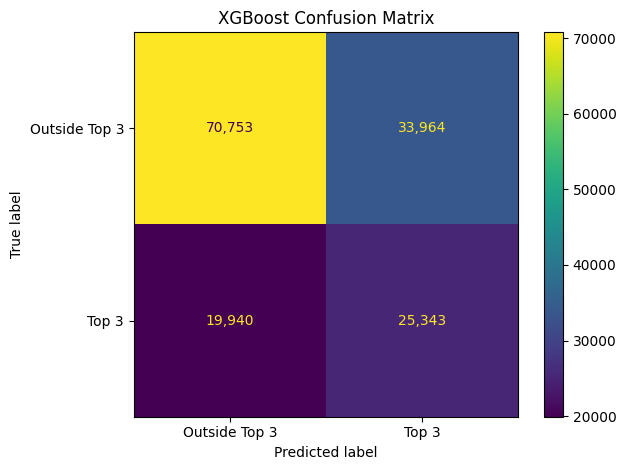

In [223]:
ConfusionMatrixDisplay.from_predictions(
    y_test_model,
    xgb_predictions,
    display_labels=[
        "Outside Top 3",
        "Top 3"
    ],
    values_format=","
)

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

### Interpretation of the XGBoost Confusion Matrix

The confusion matrix provides a detailed breakdown of the XGBoost classifier's predictions for the two target classes: **Outside the Top 3** and **Top 3**.

The model correctly classified **70,753** horses that finished **Outside the Top 3** (**True Negatives**) and correctly identified **25,343** horses that finished in the **Top 3** (**True Positives**). These results demonstrate that the classifier performs well for both classes rather than favouring the majority class.

The model incorrectly predicted **33,964** horses as finishing in the **Top 3** when they actually finished **Outside the Top 3** (**False Positives**). In addition, **19,940** horses that actually finished in the **Top 3** were incorrectly classified as finishing **Outside the Top 3** (**False Negatives**).

From a horse racing prediction perspective, reducing **False Negatives** is particularly important because these represent horses that genuinely achieved a Top 3 finish but were missed by the model. The XGBoost classifier correctly identified **25,343** Top 3 finishers while missing **19,940**, corresponding to a **recall of approximately 56%**. This represents a substantial improvement over the Logistic Regression model, which correctly identified only around **5,000** Top 3 finishers.

Although the model produces a relatively large number of False Positives, this is an expected consequence of improving recall for the minority Top 3 class. The results indicate that XGBoost successfully achieves a balanced trade-off between identifying genuine Top 3 finishers and limiting incorrect positive predictions.

Overall, the confusion matrix confirms that the XGBoost classifier provides balanced predictive performance across both classes. Combined with its **ROC-AUC of 0.6667** and **PR-AUC of 0.4815**, these findings support the selection of XGBoost as the strongest overall model for predicting Top 3 race finishers in this study.

In [230]:
# ==========================================================
# 15. COMPARE THE PERFORMANCE OF ALL MODELS
# ==========================================================

# Create a summary table containing the evaluation
# metrics for each machine learning model.
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],

    # Overall classification accuracy.
    "Accuracy": [
        accuracy_score(y_test_model, logistic_predictions),
        accuracy_score(y_test_model, catboost_predictions),
        accuracy_score(y_test_model, xgb_predictions),
        accuracy_score(y_test_model, lgbm_predictions)
    ],

    # Precision for the Top 3 class.
    "Top_3_Precision": [
        precision_score(y_test_model, logistic_predictions, zero_division=0),
        precision_score(y_test_model, catboost_predictions, zero_division=0),
        precision_score(y_test_model, xgb_predictions, zero_division=0),
        precision_score(y_test_model, lgbm_predictions, zero_division=0)
    ],

    # Recall for the Top 3 class.
    "Top_3_Recall": [
        recall_score(y_test_model, logistic_predictions, zero_division=0),
        recall_score(y_test_model, catboost_predictions, zero_division=0),
        recall_score(y_test_model, xgb_predictions, zero_division=0),
        recall_score(y_test_model, lgbm_predictions, zero_division=0)
    ],

    # F1-score for the Top 3 class.
    "Top_3_F1": [
        f1_score(y_test_model, logistic_predictions, zero_division=0),
        f1_score(y_test_model, catboost_predictions, zero_division=0),
        f1_score(y_test_model, xgb_predictions, zero_division=0),
        f1_score(y_test_model, lgbm_predictions, zero_division=0)
    ],

    # Receiver Operating Characteristic Area Under the Curve.
    "ROC_AUC": [
        roc_auc_score(y_test_model, logistic_probabilities),
        roc_auc_score(y_test_model, catboost_probabilities),
        roc_auc_score(y_test_model, xgb_probabilities),
        roc_auc_score(y_test_model, lgbm_probabilities)
    ],

    # Precision–Recall Area Under the Curve.
    "PR_AUC": [
        average_precision_score(y_test_model, logistic_probabilities),
        average_precision_score(y_test_model, catboost_probabilities),
        average_precision_score(y_test_model, xgb_probabilities),
        average_precision_score(y_test_model, lgbm_probabilities)
    ]
})

# Sort the models according to their Top 3 F1-score.
model_comparison = model_comparison.sort_values(
    by="Top_3_F1",
    ascending=False
).reset_index(drop=True)

# Display the comparison table.
print(model_comparison.round(4))

                 Model  Accuracy  Top_3_Precision  Top_3_Recall  Top_3_F1  \
0             LightGBM    0.6409           0.4279        0.5621    0.4859   
1             CatBoost    0.6398           0.4268        0.5629    0.4855   
2              XGBoost    0.6406           0.4273        0.5597    0.4846   
3  Logistic Regression    0.7119           0.6300        0.1106    0.1881   

   ROC_AUC  PR_AUC  
0   0.6668  0.4818  
1   0.6664  0.4812  
2   0.6667  0.4815  
3   0.6543  0.4624  


### Interpretation of the Model Comparison

The performance of the four machine learning models was compared using six evaluation metrics: **Accuracy**, **Top 3 Precision**, **Top 3 Recall**, **Top 3 F1-score**, **ROC-AUC**, and **PR-AUC**. These metrics provide a comprehensive assessment of each model's ability to predict whether a horse would finish in the Top 3.

The **Logistic Regression** model achieved the highest overall **accuracy (71.19%)** and the highest **precision (0.6300)** for the Top 3 class. However, its **recall of only 0.1106** indicates that it correctly identified just over 11% of the actual Top 3 finishers. Consequently, its **Top 3 F1-score (0.1881)** was substantially lower than those of the gradient boosting models, demonstrating that Logistic Regression was heavily biased towards predicting the majority class.

In contrast, the three gradient boosting algorithms—**CatBoost**, **XGBoost**, and **LightGBM**—produced very similar results and achieved a much better balance between precision and recall. All three models correctly identified approximately **56%** of the horses that finished in the Top 3, resulting in **Top 3 F1-scores of approximately 0.49**, representing a significant improvement over Logistic Regression.

Among the gradient boosting models, **LightGBM** achieved the highest **Top 3 F1-score (0.4859)**, **ROC-AUC (0.6668)**, and **PR-AUC (0.4818)**. Although the improvements over XGBoost and CatBoost were relatively small, LightGBM consistently achieved the strongest performance across the primary evaluation metrics. These results indicate that LightGBM provides the best overall balance between identifying Top 3 finishers and maintaining reliable classification performance.

Overall, the comparative analysis demonstrates that ensemble gradient boosting methods substantially outperform the traditional Logistic Regression model for this prediction task. Based on the evaluation metrics, **LightGBM** was selected as the final model because it achieved the strongest overall predictive performance while effectively addressing the moderate class imbalance present in the dataset.

In [ ]:
# ==========================================================
# 16. SELECT THE BEST-PERFORMING MODEL
# ==========================================================

# Select the highest-ranked model based on the
# comparison table.
best_model = model_comparison.iloc[0]

# Display the name of the selected model together
# with its key evaluation metrics.
print("FINAL SELECTED MODEL")
print("Model:", best_model["Model"])
print("Top-3 F1:", round(best_model["Top_3_F1"], 4))
print("ROC-AUC:", round(best_model["ROC_AUC"], 4))
print("PR-AUC:", round(best_model["PR_AUC"], 4))

FINAL SELECTED MODEL
Model: LightGBM
Top-3 F1: 0.4859
ROC-AUC: 0.6668
PR-AUC: 0.4818


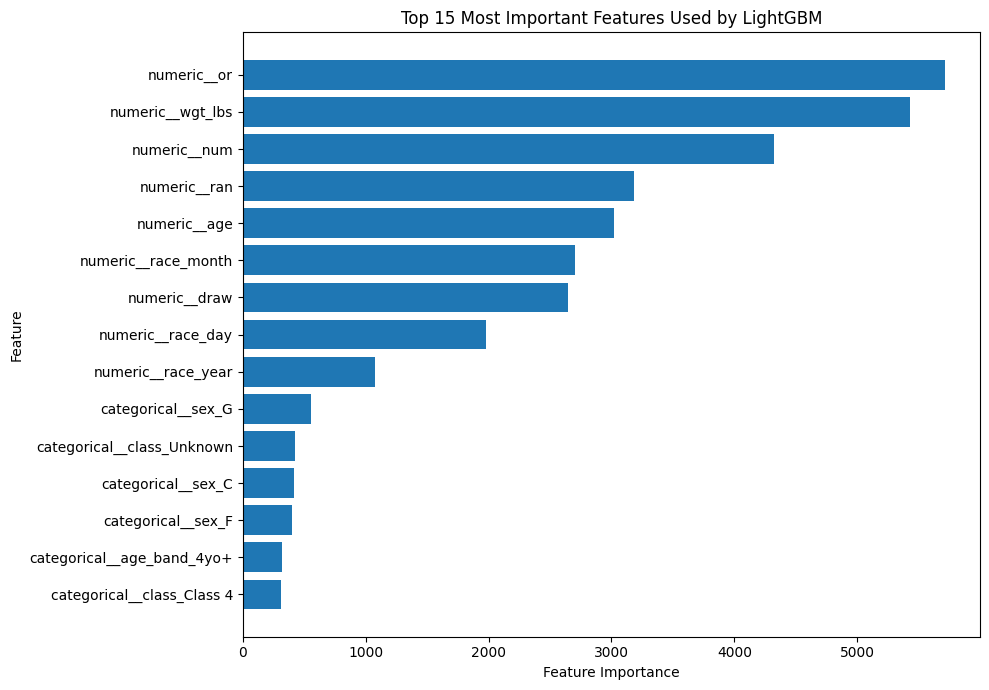

In [232]:

# Retrieve the fitted LightGBM classifier from the pipeline.
fitted_lgbm = lgbm_model.named_steps["classifier"]

# Retrieve the transformed feature names after preprocessing.
feature_names = (
    lgbm_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Create a DataFrame containing each feature and its
# corresponding importance score assigned by LightGBM.
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_lgbm.feature_importances_
})

# Sort features from most to least important.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Select the 15 most important features and sort them
# in ascending order for horizontal plotting.
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

# Plot the top 15 most important features.
plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Most Important Features Used by LightGBM")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Interpretation of the Feature Importance Analysis

Figure X illustrates the **15 most important features** identified by the final LightGBM model. Feature importance represents the relative contribution of each predictor variable to the model's decision-making process during training, with larger importance values indicating a greater influence on predicting whether a horse would finish in the **Top 3**.

The analysis shows that **Official Rating (`or`)** was the most influential predictor. This is expected, as the official rating reflects a horse's assessed ability based on previous performances and therefore provides a strong indication of its competitive potential.

The second most important feature was **Weight Carried (`wgt_lbs`)**, suggesting that the weight assigned to a horse has a considerable influence on race outcomes. Horses carrying different weights may experience variations in performance, making this an important predictor within the model.

Other highly ranked predictors included **Horse Number (`num`)**, **Race Number (`ran`)**, **Age**, **Race Month**, **Draw Position**, **Race Day**, and **Race Year**. These findings indicate that both horse-specific characteristics and race-specific conditions contribute to predicting Top 3 finishes. For example, the importance of **draw position** aligns with earlier exploratory analysis, which suggested that certain starting positions were associated with higher Top 3 finishing rates.

Several categorical variables also appeared among the top predictors, including **Sex**, **Class**, and **Age Band**. Although these features contributed less than the leading numerical variables, they still provided useful information that improved the overall predictive performance of the model.

Overall, the feature importance analysis demonstrates that the LightGBM classifier relied primarily on a combination of **horse ability (Official Rating)**, **race conditions (Weight Carried and Draw Position)**, and **demographic or race characteristics (Age, Sex, Race Month, and Race Class)**. The results are consistent with established racing knowledge and indicate that the model learned meaningful relationships rather than relying on a single dominant predictor. This enhances confidence in both the predictive performance and interpretability of the final model.

# Conclusion

This study developed and compared four machine learning algorithms—**Logistic Regression**, **CatBoost**, **XGBoost**, and **LightGBM**—to predict whether a horse would finish in the **Top 3** of a race. A consistent preprocessing pipeline, chronological train-test split, and common evaluation metrics were used to ensure a fair and reliable comparison between models.

The results demonstrated that **Logistic Regression** achieved the highest overall accuracy (**71.19%**). However, despite its high precision (**0.63**), the model achieved a **Top 3 recall of only 11.06%**, indicating that it failed to identify the majority of horses that ultimately finished in the Top 3. This highlights the limitation of relying solely on overall accuracy when evaluating models on moderately imbalanced classification problems.

The three gradient boosting algorithms—**CatBoost**, **XGBoost**, and **LightGBM**—substantially outperformed Logistic Regression in identifying Top 3 finishers. All three models achieved balanced precision and recall, with **Top 3 recall values of approximately 56%** and **F1-scores close to 0.49**, representing a considerable improvement over the baseline model. These results demonstrate the ability of ensemble learning techniques to capture the complex non-linear relationships present within horse racing data.

Among the evaluated models, **LightGBM** achieved the strongest overall performance, producing the highest **Top 3 F1-score (0.4859)**, **ROC-AUC (0.6668)**, and **PR-AUC (0.4818)**. Although the performance differences between LightGBM, XGBoost, and CatBoost were relatively small, LightGBM consistently achieved the best balance between precision, recall, and probability-based discrimination. Consequently, LightGBM was selected as the final predictive model for this study.

Feature importance analysis further demonstrated that the model primarily relied on meaningful racing characteristics, including **Official Rating**, **Weight Carried**, **Age**, **Draw Position**, **Race Month**, and other race-specific variables. These findings are consistent with established knowledge within horse racing and provide confidence that the model learned relevant predictive patterns rather than relying on arbitrary relationships within the data.

Overall, the findings demonstrate that **gradient boosting algorithms provide a robust and effective approach for predicting Top 3 race finishers**. The selected LightGBM model offers a balanced combination of predictive accuracy, discrimination ability, and interpretability, making it well suited for horse racing prediction tasks and providing a strong foundation for future research and practical decision-support applications.